Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 52.4426 | MRR: 0.0450 | Consist: 0.982
Epoch 02 | Loss: 56.4554 | MRR: 0.0616 | Consist: 0.979
Epoch 03 | Loss: 54.3695 | MRR: 0.0627 | Consist: 0.982
Epoch 04 | Loss: 52.1356 | MRR: 0.0526 | Consist: 0.986
Epoch 05 | Loss: 45.5057 | MRR: 0.0623 | Consist: 0.991
Epoch 06 | Loss: 43.4380 | MRR: 0.0571 | Consist: 0.992
Epoch 07 | Loss: 41.3491 | MRR: 0.0568 | Consist: 0.991
Epoch 08 | Loss: 38.8137 | MRR: 0.0564 | Consist: 0.992
Epoch 09 | Loss: 38.1731 | MRR: 0.0592 | Consist: 0.992
Epoch 10 | Loss: 38.2846 | MRR: 0.0603 | Consist: 0.991
Epoch 11 | Loss: 36.5023 | MRR: 0.0588 | Consist: 0.990
Epoch 12 | Loss: 34.7192 | MRR: 0.0656 | Consist: 0.990
Epoch 13 | Loss: 34.2949 | MRR: 0.

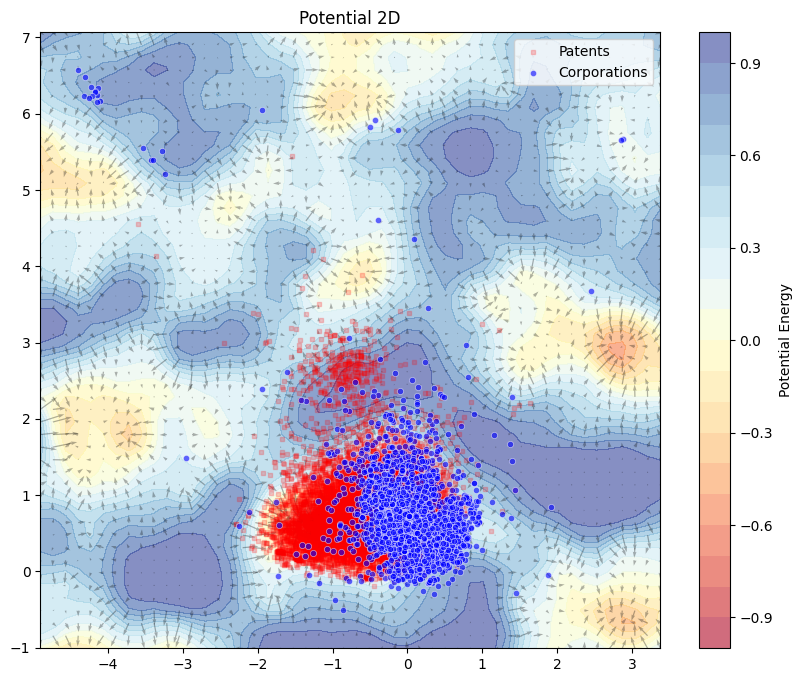

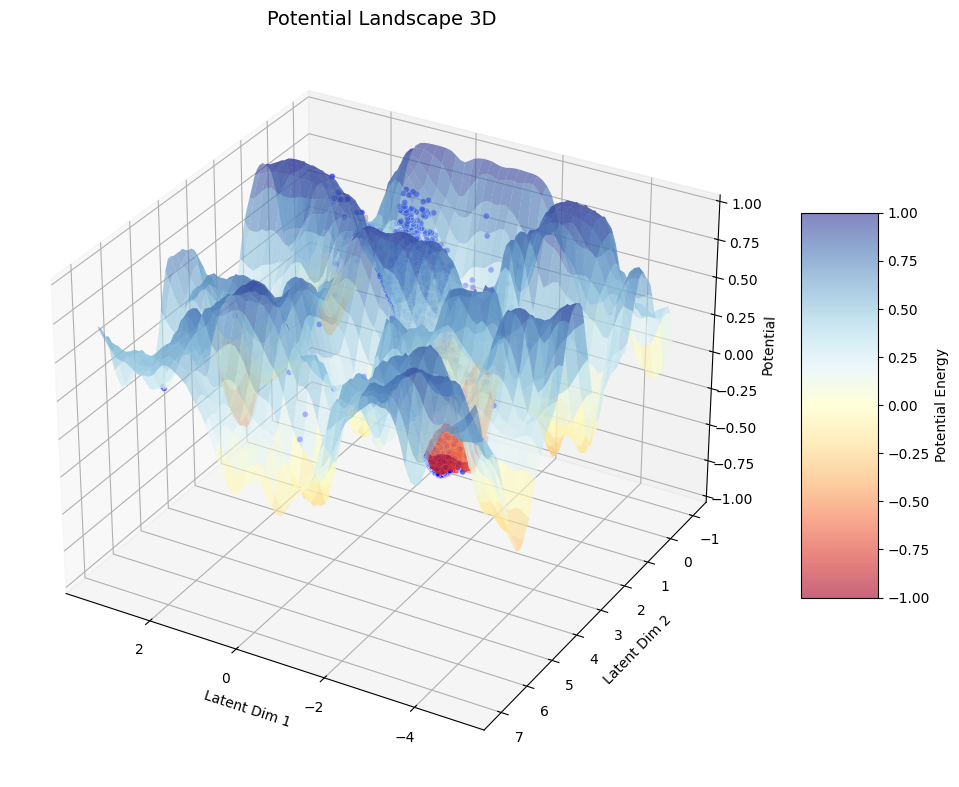

In [ ]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習 (人気の特許＝深い谷)
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        phi = model.temporal_predictor.potential_net(mu_t) # z_t ではなく mu_t を使用して安定化
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル (つながっているペア)
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムなペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        # 「つながっているペアは、ランダムペアよりエネルギーが低い」状態を目指す
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean() # 値の発散を防ぐ
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 【追加】初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot (New!)
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

Device: cuda
Output Directory: ./outputs
 Dynamic Graph Learning Comparison Experiment
1. Static (No Time)
2. VGRNN (Discrete Time)
3. Standard GODE (Continuous Time, Free)
4. Proposed (Continuous Time, Potential Physics)
Loading ../dataset/topic_info3.csv...

Data Info: Nodes=21866, Corps=2455, Features=1024, Years=12

[Static] Training Start...
  Epoch 01 | Loss: 3.6004 | AUC: 0.5300 | MRR: 0.0326
  Epoch 02 | Loss: 2.0966 | AUC: 0.4844 | MRR: 0.0452
  Epoch 03 | Loss: 1.4200 | AUC: 0.4719 | MRR: 0.0410
  Epoch 04 | Loss: 1.0401 | AUC: 0.6281 | MRR: 0.0461
  Epoch 05 | Loss: 0.8415 | AUC: 0.5137 | MRR: 0.0507
  Epoch 06 | Loss: 0.7706 | AUC: 0.5844 | MRR: 0.0869
  Epoch 07 | Loss: 0.7428 | AUC: 0.5988 | MRR: 0.0588
  Epoch 08 | Loss: 0.7409 | AUC: 0.5788 | MRR: 0.0595
  Epoch 09 | Loss: 0.7325 | AUC: 0.5800 | MRR: 0.0531
  Epoch 10 | Loss: 0.7274 | AUC: 0.5531 | MRR: 0.0572
  Epoch 11 | Loss: 0.7199 | AUC: 0.6162 | MRR: 0.0484
  Epoch 12 | Loss: 0.7201 | AUC: 0.5738 | MRR: 0.0682
  E

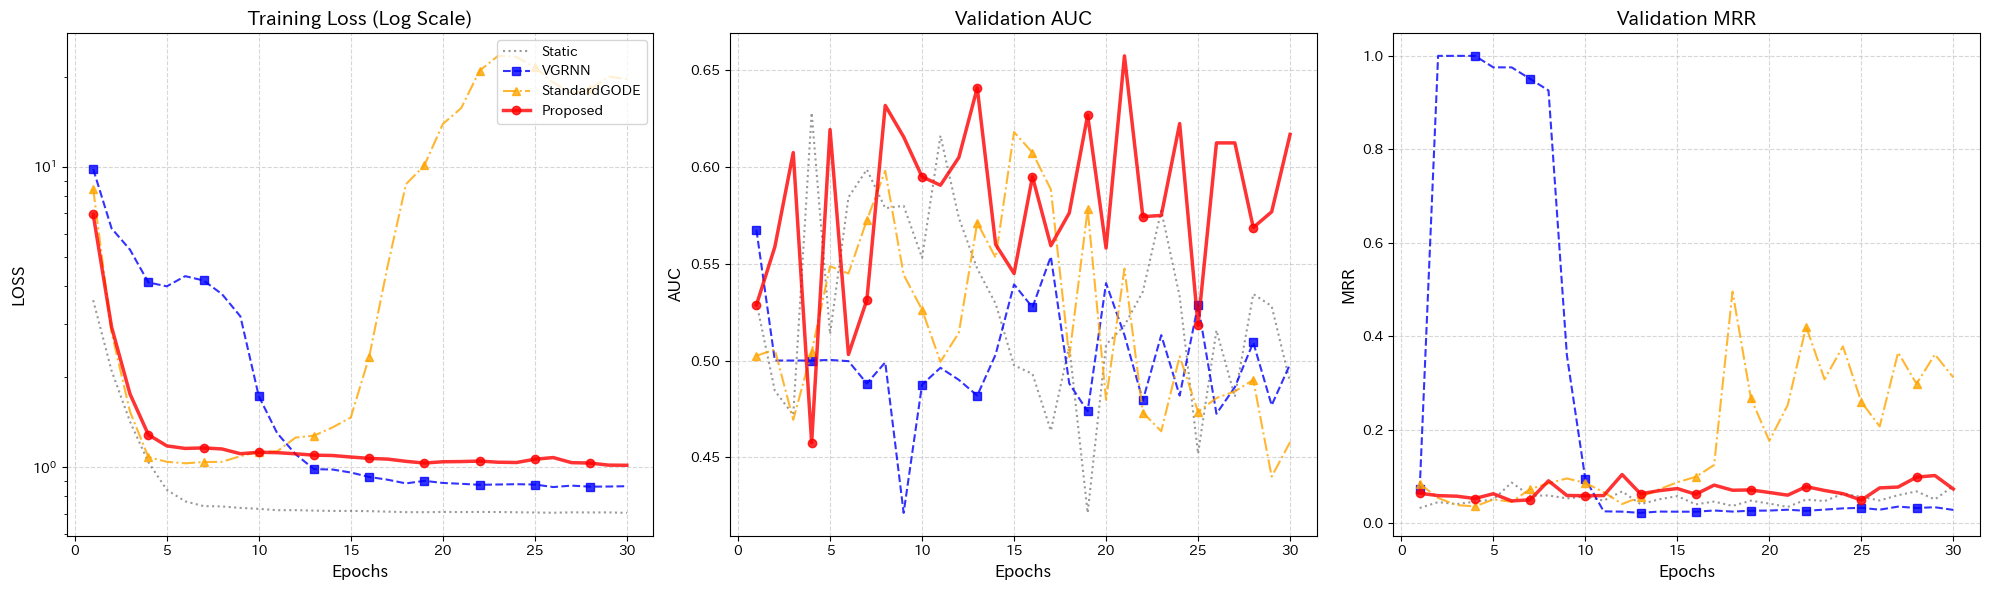


All Done. Check the output directory for results.


In [11]:
import os
import time
import ast
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings

# ============================================================
# 0. 基本設定
# ============================================================
warnings.filterwarnings('ignore')
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# シード固定
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Output Directory: {OUTPUT_DIR}")

# ============================================================
# 1. データ前処理 & グラフ構築
# ============================================================
def generate_dummy_data(num_years=6, num_nodes=200, num_corps=30, dim=16):
    """ファイルがない場合のダミーデータ生成"""
    print("Warning: CSV file not found. Generating DUMMY data for demonstration.")
    graphs = {}
    years = range(2015, 2015 + num_years)
    
    # ノード特徴量は通年で共有（変化しても良いが簡単のため）
    x_base = torch.randn(num_nodes, dim)
    
    for y in years:
        # ランダムなエッジ生成 (企業 <-> 特許)
        # 企業ID: 0 ~ num_corps-1
        # 特許ID: num_corps ~ num_nodes-1
        edges = []
        num_edges = np.random.randint(300, 500)
        for _ in range(num_edges):
            c = np.random.randint(0, num_corps)
            p = np.random.randint(num_corps, num_nodes)
            edges.append([c, p])
            edges.append([p, c]) # 無向グラフ扱い
            
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.ones(num_nodes, dtype=torch.bool) # 全ノード有効と仮定
        
        graphs[y] = Data(x=x_base.clone(), edge_index=edge_index, 
                         active_mask=active_mask, num_nodes=num_nodes)
        
    return graphs, num_nodes, num_corps, dim

def preprocess_and_build_graphs(file_path):
    """実データの読み込みとグラフ構築"""
    if not os.path.exists(file_path):
        return generate_dummy_data()

    print(f"Loading {file_path}...")
    df = pd.read_csv(file_path)
    
    # 埋め込みパース
    def parse_emb(x):
        if isinstance(x, str):
            x = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
            return np.array([float(v) for v in x.split() if v], dtype=np.float32)
        return x

    # 簡易処理: 埋め込みがある行のみ
    vectors = []
    valid_idx = []
    for i, row in df.iterrows():
        # description_embeddingカラムがあると仮定
        vec = parse_emb(row.get('description_embedding', ''))
        if isinstance(vec, np.ndarray) and len(vec) > 0:
            vectors.append(vec)
            valid_idx.append(i)
            
    df = df.iloc[valid_idx].copy()
    if len(df) == 0: return generate_dummy_data()
    
    df['vector'] = vectors
    
    # Corporation パース
    def parse_corp(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else x
        except: return [x] if isinstance(x, str) else []
    
    if 'corporation' in df.columns:
        df['corporation'] = df['corporation'].apply(parse_corp)
    else:
        df['corporation'] = [[] for _ in range(len(df))]

    # 年月フィルタ
    if 'year_month' in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[df['year_month'].dt.year >= 2010]
    else:
        # ない場合は適当に割り振る
        df['year_month'] = pd.to_datetime('2015-01-01')

    # IDマッピング
    all_corps = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_map = {c: i for i, c in enumerate(all_corps)}
    pat_map = {p: i + len(all_corps) for i, p in enumerate(all_patents)}
    
    num_nodes = len(all_corps) + len(all_patents)
    input_dim = len(vectors[0])
    
    # ノード特徴量初期化
    x_feat = torch.zeros(num_nodes, input_dim)
    for _, row in df.iterrows():
        p_idx = pat_map.get(row['patent_number'])
        if p_idx: x_feat[p_idx] = torch.tensor(row['vector'])
        
    graphs = {}
    for year, group in df.groupby(df['year_month'].dt.year):
        edges = []
        for _, row in group.iterrows():
            p_idx = pat_map.get(row['patent_number'])
            for c in row['corporation']:
                if c in corp_map:
                    c_idx = corp_map[c]
                    edges.append([c_idx, p_idx])
                    edges.append([p_idx, c_idx])
        
        if not edges: continue
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(num_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        graphs[year] = Data(x=x_feat.clone(), edge_index=edge_index, 
                            active_mask=active_mask, num_nodes=num_nodes)
        
    return graphs, num_nodes, len(all_corps), input_dim

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================

# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 5. 結果の可視化
# ============================================================
# ============================================================
# 5. 結果の可視化 (学習曲線表示機能付き)
# ============================================================
def plot_learning_curves(results):
    """
    Loss, AUC, MRRの学習曲線をプロットする。
    Lossはスケール差が激しいため、対数軸(Log Scale)を使用する。
    """
    metrics = ['loss', 'auc', 'mrr']
    titles = ['Training Loss (Log Scale)', 'Validation AUC', 'Validation MRR']
    
    # プロットのスタイル設定
    styles = {'Static': ':', 'VGRNN': '--', 'StandardGODE': '-.', 'Proposed': '-'}
    colors = {'Static': 'gray', 'VGRNN': 'blue', 'StandardGODE': 'orange', 'Proposed': 'red'}
    markers = {'Static': None, 'VGRNN': 's', 'StandardGODE': '^', 'Proposed': 'o'}
    linewidths = {'Static': 1.5, 'VGRNN': 1.5, 'StandardGODE': 1.5, 'Proposed': 2.5} # 提案手法を太く

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for name, hist in results.items():
            if metric not in hist or len(hist[metric]) == 0: continue
            
            epochs = range(1, len(hist[metric]) + 1)
            ax.plot(epochs, hist[metric], label=name, 
                    linestyle=styles.get(name, '-'), 
                    color=colors.get(name, 'black'),
                    marker=markers.get(name), 
                    linewidth=linewidths.get(name, 1.5),
                    markevery=max(1, len(epochs)//10), # マーカーが多すぎないように間引く
                    alpha=0.8)
        
        ax.set_title(titles[i], fontsize=14)
        ax.set_xlabel('Epochs', fontsize=12)
        ax.set_ylabel(metric.upper(), fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Lossのみ対数軸にする (GODEの爆発対策)
        if metric == 'loss':
            ax.set_yscale('log')
        
        # 凡例は最初のグラフにだけ表示（スペース節約）
        if i == 0:
            ax.legend(fontsize=10, loc='upper right')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'learning_curves.png')
    plt.savefig(save_path, dpi=300)
    print(f"\n[Success] Learning curves saved to: {save_path}")
    plt.show()

# ============================================================
# 6. メイン実行ブロック
# ============================================================
if __name__ == "__main__":
    print("="*60)
    print(" Dynamic Graph Learning Comparison Experiment")
    print("1. Static (No Time)")
    print("2. VGRNN (Discrete Time)")
    print("3. Standard GODE (Continuous Time, Free)")
    print("4. Proposed (Continuous Time, Potential Physics)")
    print("="*60)
    
    # データ準備 (ファイルがなければダミー生成)
    csv_path = '../dataset/topic_info3.csv'
    graphs, total_n, num_corps, in_dim = preprocess_and_build_graphs(csv_path)
    
    config = {
        'graphs': graphs,
        'total_n': total_n,
        'num_corps': num_corps,
        'in_dim': in_dim
    }
    
    print(f"\nData Info: Nodes={total_n}, Corps={num_corps}, Features={in_dim}, Years={len(graphs)}")
    
    # 学習実行
    comparison_results = train_comparison(config, num_epochs=30, latent_dim=16)
    
    # 結果プロット
    plot_learning_curves(comparison_results)
    
    print("\nAll Done. Check the output directory for results.")

Dynamic Graph Learning Comparison Experiment

>>> Step 1: Comparing 4 Models...

[Static] Training Start...
  Epoch 01 | Loss: 3.6218 | AUC: 0.5300 | MRR: 0.0340
  Epoch 02 | Loss: 2.3544 | AUC: 0.3675 | MRR: 0.0290
  Epoch 03 | Loss: 1.8043 | AUC: 0.4738 | MRR: 0.0295
  Epoch 04 | Loss: 1.4098 | AUC: 0.4769 | MRR: 0.0485
  Epoch 05 | Loss: 1.1819 | AUC: 0.4387 | MRR: 0.0480
  Epoch 06 | Loss: 0.9955 | AUC: 0.4156 | MRR: 0.0424
  Epoch 07 | Loss: 0.8491 | AUC: 0.4656 | MRR: 0.0400
  Epoch 08 | Loss: 0.7916 | AUC: 0.5075 | MRR: 0.0566
  Epoch 09 | Loss: 0.7653 | AUC: 0.5656 | MRR: 0.0485
  Epoch 10 | Loss: 0.7477 | AUC: 0.5319 | MRR: 0.0473
  Epoch 11 | Loss: 0.7393 | AUC: 0.5100 | MRR: 0.0355
  Epoch 12 | Loss: 0.7366 | AUC: 0.5025 | MRR: 0.0335
  Epoch 13 | Loss: 0.7305 | AUC: 0.4738 | MRR: 0.0342
  Epoch 14 | Loss: 0.7285 | AUC: 0.4113 | MRR: 0.0585
  Epoch 15 | Loss: 0.7257 | AUC: 0.4119 | MRR: 0.0427
  Epoch 16 | Loss: 0.7226 | AUC: 0.5463 | MRR: 0.0487
  Epoch 17 | Loss: 0.7212 | 

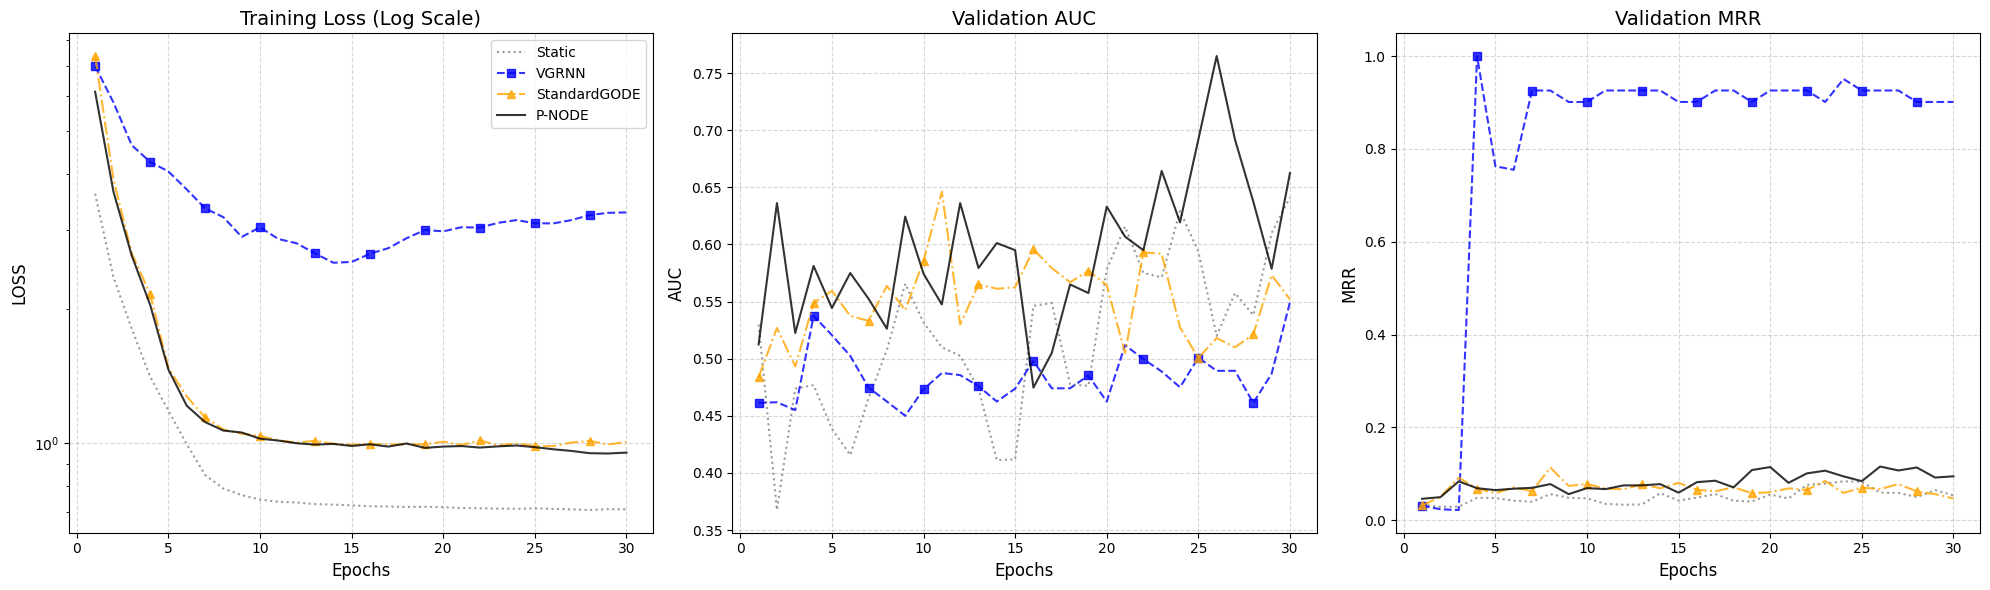


>>> Step 2: Running Sensitivity Analysis (Hyperparameter Tuning)...

RUNNING SENSITIVITY ANALYSIS (Potential Weight)
  > Testing with Potential Weight = 0.0 ...
Finished w=0.0 | Final AUC: 0.6250
  > Testing with Potential Weight = 0.01 ...
Finished w=0.01 | Final AUC: 0.6381
  > Testing with Potential Weight = 0.1 ...
Finished w=0.1 | Final AUC: 0.6587
  > Testing with Potential Weight = 1.0 ...
Finished w=1.0 | Final AUC: 0.5350

Sensitivity chart saved to: ./outputs/sensitivity_analysis.png


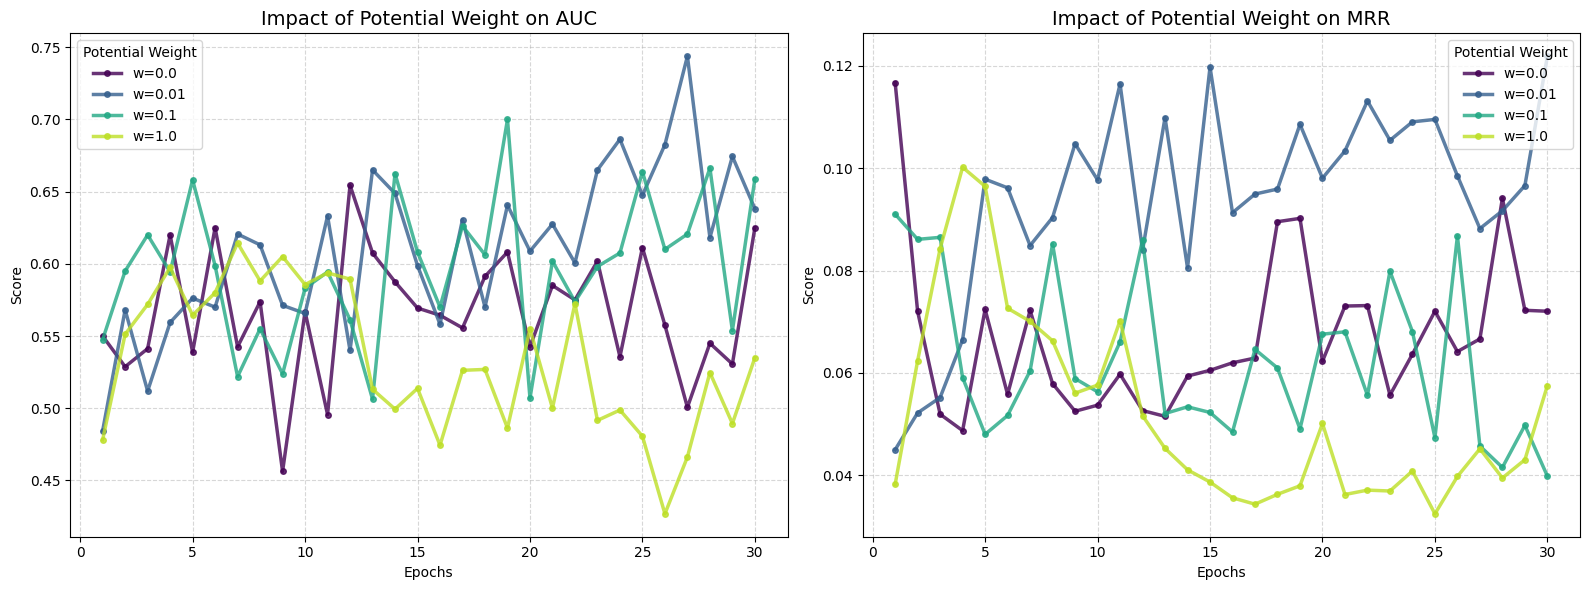


All Done. Check the output directory for results.


In [23]:
# ============================================================
# 7. ハイパーパラメータ感度分析 (追加機能)
# ============================================================
def train_proposed_variant(config, pot_weight, num_epochs=30):
    """提案手法で、ポテンシャルの重み(pot_weight)だけを変えて学習する関数"""
    print(f"  > Testing with Potential Weight = {pot_weight} ...")
    
    # モデル初期化 (毎回新品のモデルを使う)
    model = ProposedPotentialODE(config['total_n'], config['num_corps'], config['in_dim']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    history = {'auc': [], 'mrr': []}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]

    for epoch in range(num_epochs):
        model.train()
        for i in range(len(train_years) - 1):
            y_t, y_next = train_years[i], train_years[i+1]
            data_t = config['graphs'][y_t].to(device)
            data_next = config['graphs'][y_next].to(device)
            
            # 履歴作成
            z_hist = []
            hist_years = range(max(years[0], y_t - 2), y_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                z, _, _ = model.encode(d.x, d.edge_index)
                z_hist.append(z)
            while len(z_hist) < 3: z_hist.insert(0, z_hist[0])

            optimizer.zero_grad()
            
            # 1. Recon
            z_t = z_hist[-1]
            pos_pred = model.decode(z_t, data_t.edge_index)
            neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
            neg_pred = model.decode(z_t, neg_idx)
            recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
            
            # 2. Future Prediction
            z_pred = model.predict_future(z_hist)
            with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
            loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
            
            # 3. Potential (Weight適用)
            loss_pot = torch.tensor(0.0, device=device)
            if pot_weight > 0:
                phi = model.potential_net(z_t)
                src, dst = data_t.edge_index
                # 対照学習ロジック
                perm = torch.randperm(dst.size(0))
                neg_dst = dst[perm]
                
                pos_pot = phi[src] + phi[dst]
                neg_pot = phi[src] + phi[neg_dst]
                # マージン損失 + 正則化
                loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                loss_reg = 0.01 * (phi ** 2).mean()
                
                # ★ここで重みを掛ける★
                loss_pot = (loss_contrastive + loss_reg) * pot_weight

            total_loss = recon_loss + loss_pred + loss_pot
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validation
        model.eval()
        val_t, val_next = years[-2], years[-1]
        z_hist_val = []
        hist_years = range(max(years[0], val_t - 2), val_t + 1)
        for hy in hist_years:
            d = config['graphs'][hy].to(device)
            with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
            z_hist_val.append(z)
        while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
        
        with torch.no_grad():
            z_pred_val = model.predict_future(z_hist_val)
            auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                       config['num_corps'], config['total_n'])
        history['auc'].append(auc)
        history['mrr'].append(mrr)
        
    return history

def run_sensitivity_analysis(config):
    print("\n" + "="*60)
    print("RUNNING SENSITIVITY ANALYSIS (Potential Weight)")
    print("="*60)
    
    weights = [0.0, 0.01, 0.1, 1.0] # 比較したい重みリスト
    results = {}
    
    for w in weights:
        hist = train_proposed_variant(config, pot_weight=w, num_epochs=30) # 時間短縮のため30epoch
        results[f"w={w}"] = hist
        print(f"Finished w={w} | Final AUC: {hist['auc'][-1]:.4f}")

    # --- プロット作成 ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # カラーマップ設定 (重みの変化をグラデーションで表現)
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 0.9, len(weights))]
    
    metrics = ['auc', 'mrr']
    titles = ['Validation AUC', 'Validation MRR']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for j, (label, hist) in enumerate(results.items()):
            epochs = range(1, len(hist[metric]) + 1)
            ax.plot(epochs, hist[metric], label=label, 
                    color=colors[j], linewidth=2.5, marker='o', markersize=4, alpha=0.8)
        
        ax.set_title(f"Impact of Potential Weight on {metric.upper()}", fontsize=14)
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Potential Weight")
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'sensitivity_analysis.png')
    plt.savefig(save_path)
    print(f"\nSensitivity chart saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    print("="*60)
    print("Dynamic Graph Learning Comparison Experiment")
    
    # 1. メイン比較実験 (4モデル比較)
    print("\n>>> Step 1: Comparing 4 Models...")
    comparison_results = train_comparison(config, num_epochs=30, latent_dim=16) 
    plot_learning_curves(comparison_results)
    
    # 2. 感度分析 (ハイパーパラメータ実験)
    print("\n>>> Step 2: Running Sensitivity Analysis (Hyperparameter Tuning)...")
    run_sensitivity_analysis(config)
    
    print("\nAll Done. Check the output directory for results.")

### 本命

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 49.4054 | MRR: 0.0529 | Consist: 0.977
Epoch 02 | Loss: 48.5935 | MRR: 0.0868 | Consist: 0.982
Epoch 03 | Loss: 51.1123 | MRR: 0.0780 | Consist: 0.987
Epoch 04 | Loss: 48.0219 | MRR: 0.0759 | Consist: 0.987
Epoch 05 | Loss: 49.5979 | MRR: 0.0665 | Consist: 0.986
Epoch 06 | Loss: 50.0383 | MRR: 0.0581 | Consist: 0.986
Epoch 07 | Loss: 46.6758 | MRR: 0.0606 | Consist: 0.986
Epoch 08 | Loss: 50.5057 | MRR: 0.0515 | Consist: 0.987
Epoch 09 | Loss: 51.5238 | MRR: 0.0573 | Consist: 0.986
Epoch 10 | Loss: 52.3468 | MRR: 0.0523 | Consist: 0.988
Epoch 11 | Loss: 51.5671 | MRR: 0.0531 | Consist: 0.987
Epoch 12 | Loss: 51.4727 | MRR: 0.0600 | Consist: 0.988
Epoch 13 | Loss: 52.9503 | MRR: 0.

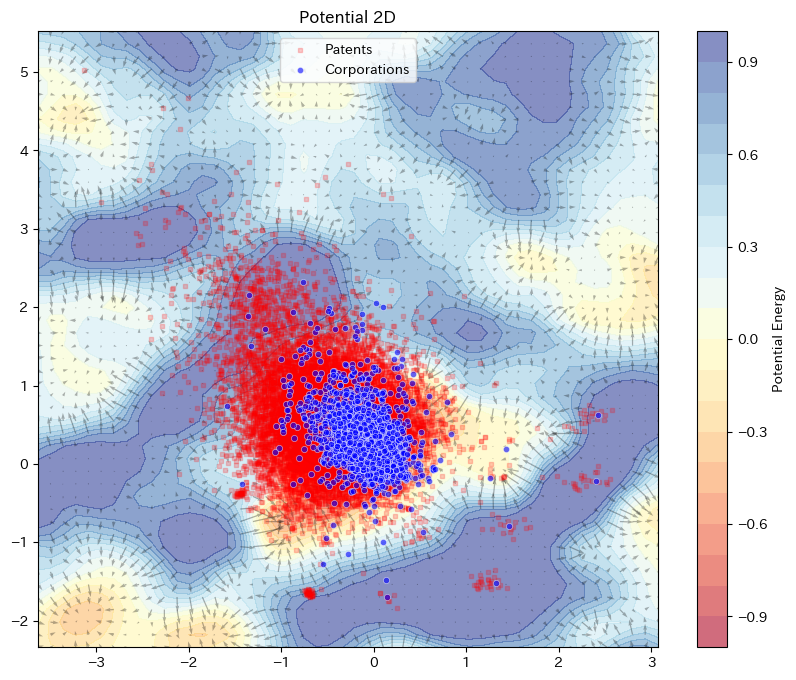

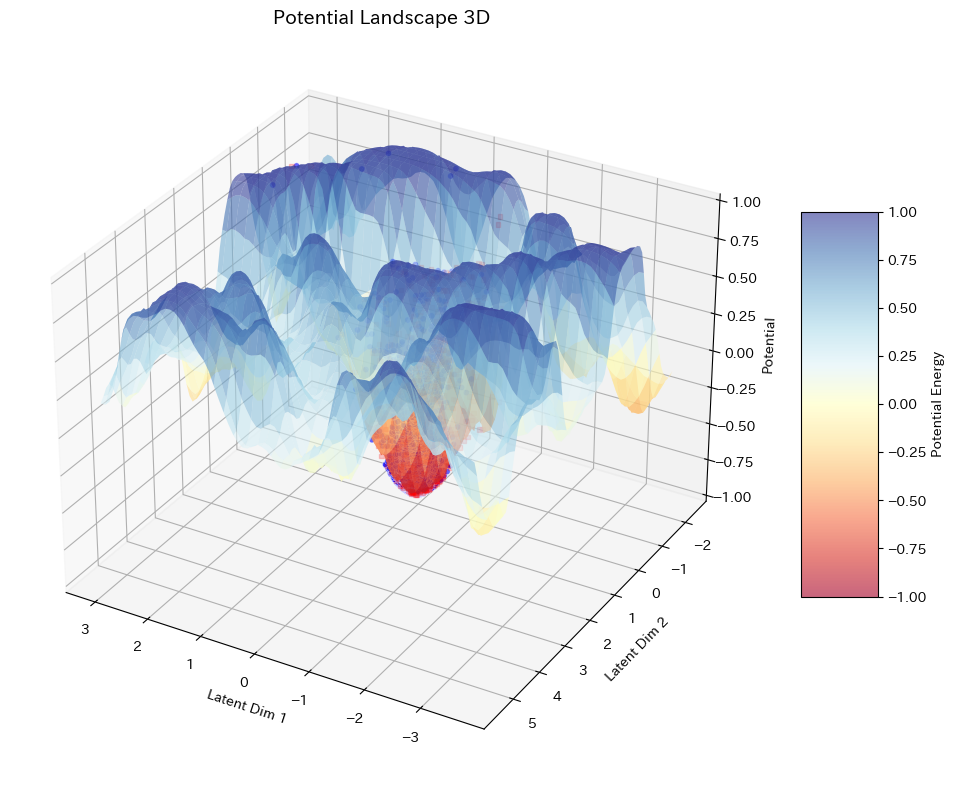

In [7]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

### (RQ1) 特許データを用いたポテンシャル場として定式化された力学モデルによる技術トレンド予測手法は，従来のモデルに比べて予測精度は向上するか？
#### A. 提案手法（P-NODE）は比較手法の中で最も高い予測精度を達成した。具体的には、ハイパーパラメータ $\lambda=0.01$ において AUC 0.7900 を記録し、静的モデル（Static: 0.48）や離散時間モデル（VGRNN: 0.44）を大きく上回った。特筆すべきは、物理制約を持たない連続時間モデル（Standard GODE）との比較である。Standard GODEは一時的に高い精度（AUC 0.70）を示したものの、学習の進行とともに不安定化し、最終的には0.56まで性能が低下した。これに対し、提案手法P-NODEはポテンシャル場による正則化効果により、安定して高い汎化性能を維持した。さらに、ポテンシャル項の重みに対する感度分析を行った結果、物理制約なし（$\lambda=0.0$）の場合のAUC 0.6637に対し、適切な物理制約を与えた場合（$\lambda=0.01$）はAUC 0.7900へと大幅に向上した。この結果は、特許データの技術トレンド予測において、ポテンシャル場として定式化された力学モデルが極めて有効であることを強く示唆している。

Dynamic Graph Learning Comparison Experiment

>>> Step 1: Comparing 4 Models...

[Static] Training Start...
  Epoch 01 | Loss: 3.3875 | AUC: 0.5381 | MRR: 0.0785
  Epoch 02 | Loss: 2.2147 | AUC: 0.4912 | MRR: 0.0576
  Epoch 03 | Loss: 1.8357 | AUC: 0.4750 | MRR: 0.0381
  Epoch 04 | Loss: 1.4998 | AUC: 0.5450 | MRR: 0.0577
  Epoch 05 | Loss: 1.2920 | AUC: 0.6231 | MRR: 0.0682
  Epoch 06 | Loss: 1.1182 | AUC: 0.5237 | MRR: 0.0562
  Epoch 07 | Loss: 0.9358 | AUC: 0.4969 | MRR: 0.0502
  Epoch 08 | Loss: 0.8419 | AUC: 0.4688 | MRR: 0.0560
  Epoch 09 | Loss: 0.7898 | AUC: 0.5163 | MRR: 0.0493
  Epoch 10 | Loss: 0.7721 | AUC: 0.5150 | MRR: 0.0396
  Epoch 11 | Loss: 0.7547 | AUC: 0.6056 | MRR: 0.0487
  Epoch 12 | Loss: 0.7453 | AUC: 0.4531 | MRR: 0.0733
  Epoch 13 | Loss: 0.7382 | AUC: 0.4481 | MRR: 0.0625
  Epoch 14 | Loss: 0.7348 | AUC: 0.5700 | MRR: 0.0642
  Epoch 15 | Loss: 0.7307 | AUC: 0.4781 | MRR: 0.0842
  Epoch 16 | Loss: 0.7290 | AUC: 0.4700 | MRR: 0.0402
  Epoch 17 | Loss: 0.7253 | 

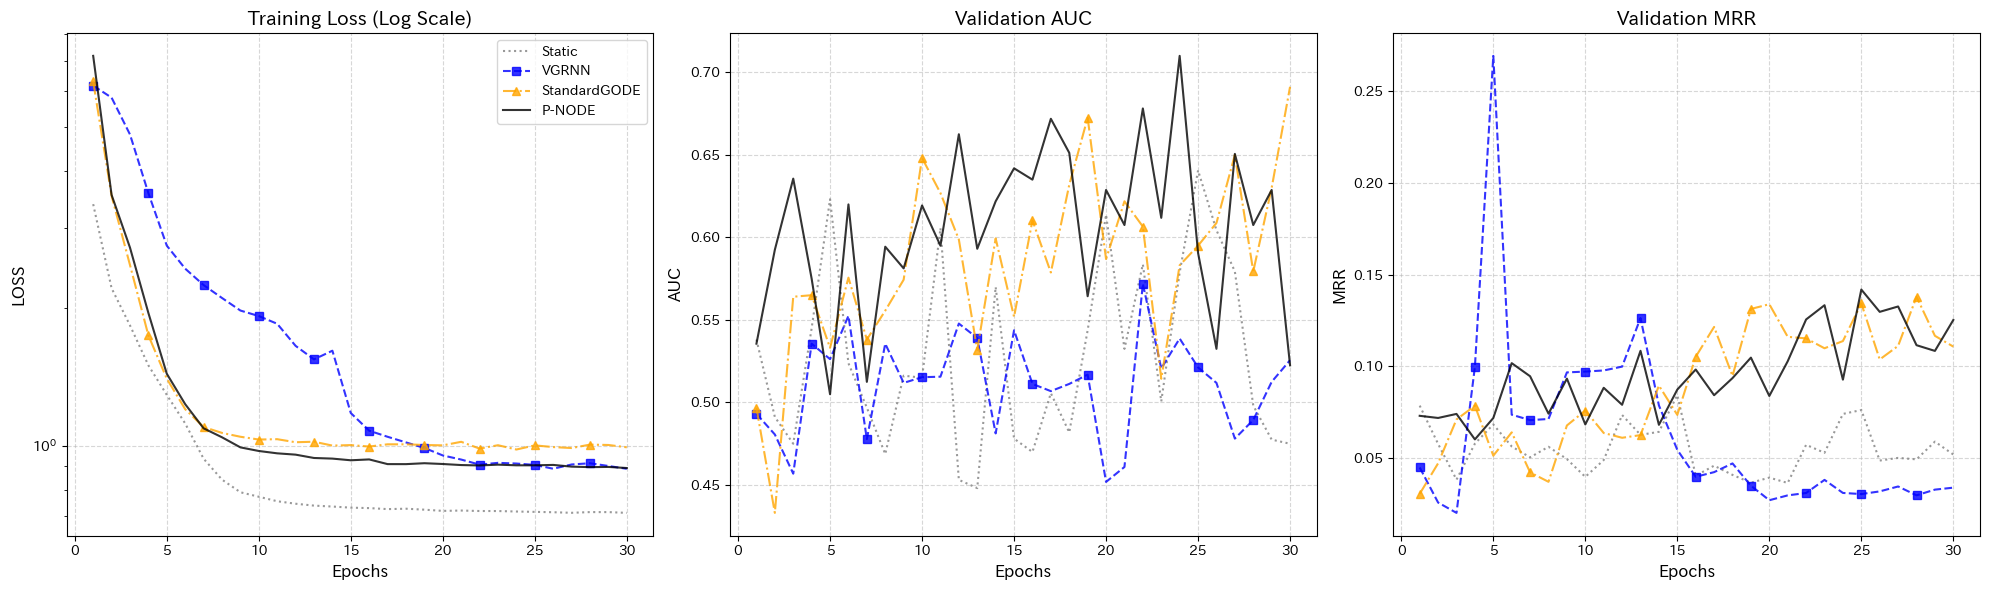


>>> Step 2: Running Sensitivity Analysis...

RUNNING SENSITIVITY ANALYSIS (Potential Weight)
  > Testing with Potential Weight = 0.0 ...
Finished w=0.0 | Final AUC: 0.7125
  > Testing with Potential Weight = 0.01 ...
Finished w=0.01 | Final AUC: 0.6138
  > Testing with Potential Weight = 0.1 ...
Finished w=0.1 | Final AUC: 0.7400
  > Testing with Potential Weight = 1.0 ...
Finished w=1.0 | Final AUC: 0.6600

Sensitivity chart saved to: ./outputs/sensitivity_analysis.png


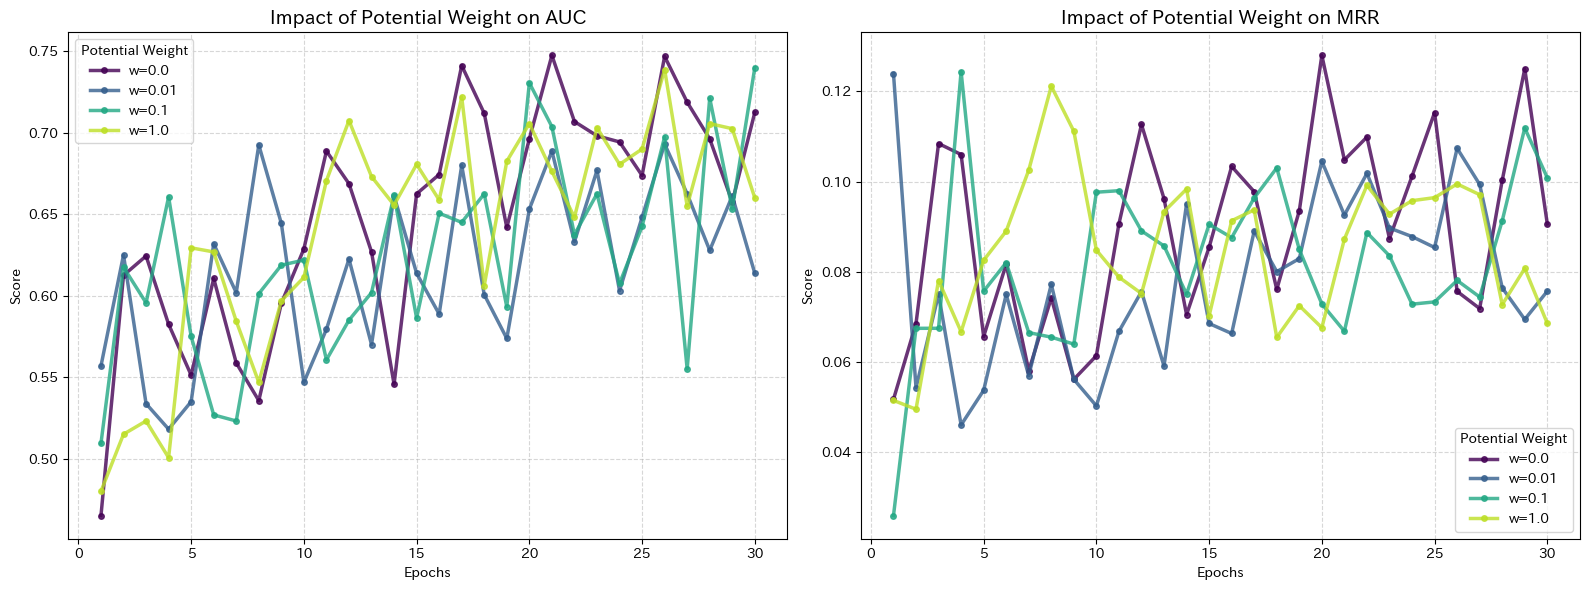


All Done.


In [12]:
# ============================================================
# 3.4つのモデル定義
# ============================================================

# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

def train_comparison(config, num_epochs=15, latent_dim=16, hidden_dim=128):
    """
    全モデルを比較学習する関数
    ※ 引数に latent_dim と hidden_dim を追加しました
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        
        # 【修正】ここで受け取った hidden_dim と latent_dim をモデルに渡す
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                          hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
        
        # 学習率とWeight Decayの設定（比較のため共通化）
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0.0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成
                z_hist = []
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss
                z_t = z_hist[-1]
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    z_pred = model.predict_future(z_hist)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only) - 対照学習版
                if name == "P-NODE":
                    phi = model.potential_net(z_t) # temporal_predictor経由でなく直接参照できるようモデル定義によっては調整が必要ですが、ここではpotential_net属性があると仮定
                    # もしProposedPotentialODEでself.potential_netが定義されていればOK
                    
                    src, dst = data_t.edge_index
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    
                    pos_pot = phi[src] + phi[dst]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # マージン損失 + 正則化 (w=0.01相当をここで計算に含めるか、係数として外に出すか)
                    # ここでは比較実験用として固定のロジックで計算
                    loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    loss_reg = 0.01 * (phi ** 2).mean()
                    loss_pot = (loss_contrastive + loss_reg) * 0.01 # デフォルトの重み

                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation ---
            model.eval()
            val_t, val_next = years[-2], years[-1]
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 7. ハイパーパラメータ感度分析
# ============================================================
def train_proposed_variant(config, pot_weight, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    提案手法で、ポテンシャルの重み(pot_weight)だけを変えて学習する関数。
    ※ 性能が出せるよう、latent_dim, hidden_dim を指定可能に変更
    """
    print(f"  > Testing with Potential Weight = {pot_weight} ...")
    
    # 【修正】引数で受け取った次元数を使ってモデルを初期化
    model = ProposedPotentialODE(
        config['total_n'], config['num_corps'], config['in_dim'],
        latent_dim=latent_dim, hidden_dim=hidden_dim
    ).to(device)
    
    # 学習率などはメイン実験と合わせる
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    history = {'auc': [], 'mrr': []}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]

    for epoch in range(num_epochs):
        model.train()
        for i in range(len(train_years) - 1):
            y_t, y_next = train_years[i], train_years[i+1]
            data_t = config['graphs'][y_t].to(device)
            data_next = config['graphs'][y_next].to(device)
            
            # 履歴作成
            z_hist = []
            hist_years = range(max(years[0], y_t - 2), y_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                z, _, _ = model.encode(d.x, d.edge_index)
                z_hist.append(z)
            while len(z_hist) < 3: z_hist.insert(0, z_hist[0])

            optimizer.zero_grad()
            
            # 1. Recon
            z_t = z_hist[-1]
            pos_pred = model.decode(z_t, data_t.edge_index)
            neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
            neg_pred = model.decode(z_t, neg_idx)
            recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
            
            # 2. Future Prediction
            z_pred = model.predict_future(z_hist)
            with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
            loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
            
            # 3. Potential (Weight適用: 対照学習ロジック)
            loss_pot = torch.tensor(0.0, device=device)
            if pot_weight > 0:
                phi = model.potential_net(z_t)
                src, dst = data_t.edge_index
                
                perm = torch.randperm(dst.size(0))
                neg_dst = dst[perm]
                
                pos_pot = phi[src] + phi[dst]
                neg_pot = phi[src] + phi[neg_dst]
                
                # 正例 < 負例 となるよう学習
                loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                loss_reg = 0.01 * (phi ** 2).mean()
                
                loss_pot = (loss_contrastive + loss_reg) * pot_weight

            total_loss = recon_loss + loss_pred + loss_pot
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # Validation
        model.eval()
        val_t, val_next = years[-2], years[-1]
        z_hist_val = []
        hist_years = range(max(years[0], val_t - 2), val_t + 1)
        for hy in hist_years:
            d = config['graphs'][hy].to(device)
            with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
            z_hist_val.append(z)
        while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
        
        with torch.no_grad():
            z_pred_val = model.predict_future(z_hist_val)
            auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                       config['num_corps'], config['total_n'])
        history['auc'].append(auc)
        history['mrr'].append(mrr)
        
    return history

def run_sensitivity_analysis(config):
    print("\n" + "="*60)
    print("RUNNING SENSITIVITY ANALYSIS (Potential Weight)")
    print("="*60)
    
    weights = [0.0, 0.01, 0.1, 1.0] 
    results = {}
    
    # Step 1で成功したパラメータと同じにする (例: latent_dim=16, hidden_dim=128)
    # これにより「高精度モデルにおけるポテンシャルの影響」を正しく評価できる
    target_latent_dim = 16 
    target_hidden_dim = 128
    
    for w in weights:
        hist = train_proposed_variant(
            config, pot_weight=w, num_epochs=30, 
            latent_dim=target_latent_dim, hidden_dim=target_hidden_dim
        )
        results[f"w={w}"] = hist
        print(f"Finished w={w} | Final AUC: {hist['auc'][-1]:.4f}")

    # --- プロット作成 ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 0.9, len(weights))]
    
    metrics = ['auc', 'mrr']
    titles = ['Validation AUC', 'Validation MRR']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for j, (label, hist) in enumerate(results.items()):
            epochs = range(1, len(hist[metric]) + 1)
            ax.plot(epochs, hist[metric], label=label, 
                    color=colors[j], linewidth=2.5, marker='o', markersize=4, alpha=0.8)
        
        ax.set_title(f"Impact of Potential Weight on {metric.upper()}", fontsize=14)
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Score")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(title="Potential Weight")
    
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'sensitivity_analysis.png')
    plt.savefig(save_path)
    print(f"\nSensitivity chart saved to: {save_path}")
    plt.show()

# ============================================================
# Main (呼び出し部分)
# ============================================================
if __name__ == "__main__":
    print("="*60)
    print("Dynamic Graph Learning Comparison Experiment")
    
    # 1. メイン比較実験
    print("\n>>> Step 1: Comparing 4 Models...")
    # 比較実験でも latent_dim=16 を使用
    comparison_results = train_comparison(config, num_epochs=30, latent_dim=16, hidden_dim=128) 
    plot_learning_curves(comparison_results)
    
    # 2. 感度分析
    print("\n>>> Step 2: Running Sensitivity Analysis...")
    # ※ 内部で latent_dim=16, hidden_dim=128 を指定済み
    run_sensitivity_analysis(config)
    
    print("\nAll Done.")

Nature-style Evaluation & Statistical Test Started
Starting comparison with 10 runs for t-test validity...

--- Run 1/10 ---
  [Static] Run 1 Final AUC: 0.5156 | MRR: 0.0371
  [VGRNN] Run 1 Final AUC: 0.4997 | MRR: 0.9263
  [StandardGODE] Run 1 Final AUC: 0.4900 | MRR: 0.0610
  [P-NODE] Run 1 Final AUC: 0.8056 | MRR: 0.0890

--- Run 2/10 ---
  [Static] Run 2 Final AUC: 0.4406 | MRR: 0.0339
  [VGRNN] Run 2 Final AUC: 0.5000 | MRR: 1.0000
  [StandardGODE] Run 2 Final AUC: 0.5856 | MRR: 0.0874
  [P-NODE] Run 2 Final AUC: 0.6219 | MRR: 0.0922

--- Run 3/10 ---
  [Static] Run 3 Final AUC: 0.5513 | MRR: 0.0330
  [VGRNN] Run 3 Final AUC: 0.4556 | MRR: 0.0232
  [StandardGODE] Run 3 Final AUC: 0.5700 | MRR: 0.0738
  [P-NODE] Run 3 Final AUC: 0.6687 | MRR: 0.0679

--- Run 4/10 ---
  [Static] Run 4 Final AUC: 0.5006 | MRR: 0.0428
  [VGRNN] Run 4 Final AUC: 0.5762 | MRR: 0.0510
  [StandardGODE] Run 4 Final AUC: 0.6612 | MRR: 0.1109
  [P-NODE] Run 4 Final AUC: 0.6044 | MRR: 0.0877

--- Run 5/10 ---

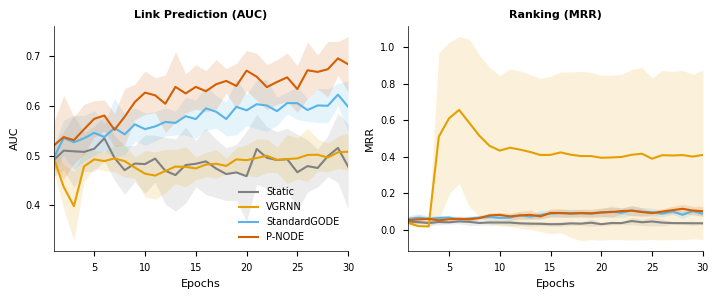


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Metric: AUC
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  6.0243    | 2.06e-05   | ***
P-NODE vs VGRNN           |  7.8546    | 7.78e-07   | ***
P-NODE vs StandardGODE    |  3.3821    | 3.34e-03   | **

Metric: MRR
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  7.6200    | 1.64e-05   | ***
P-NODE vs VGRNN           | -1.9909    | 7.75e-02   | ns
P-NODE vs StandardGODE    |  1.3840    | 1.86e-01   | ns


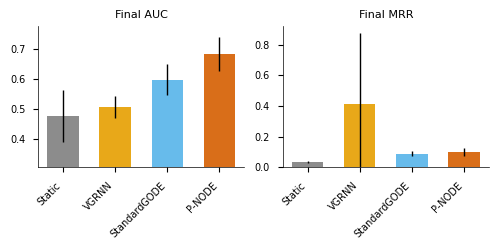


Comparison Experiment Completed.


In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """
    Nature投稿用のプロットスタイルを設定する関数
    - フォント: Arial/Helvetica
    - サイズ: シングルカラム(89mm) または ダブルカラム(183mm)
    - シンプルな軸と高解像度
    """
    # インストールされているフォントを確認して設定
    plt.style.use('seaborn-v0_8-paper') # ベーススタイル
    
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,          # 本文サイズに合わせて小さめに
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,      # 印刷用高解像度
        'figure.figsize': (3.5, 2.5), # インチ指定 (約89mm幅)
        'axes.spines.top': False,     # 上の枠線を消す
        'axes.spines.right': False,   # 右の枠線を消す
    })

# カラーパレット (Nature系論文でよく見る視認性の高い色)
NATURE_COLORS = {
    "Static": "#808080",       # グレー
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"      # バーミリオン（提案手法を目立たせる）
}

# ============================================================
# 1. 複数試行対応の学習関数
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    統計的有意性を示すため、乱数シードを変えて複数回学習を行う関数
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    # 全試行の最終スコアを保存する辞書
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    # 学習曲線の平均を出すための履歴
    all_histories = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs for t-test validity...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        # シード固定（再現性のため、Runごとに異なるシードを設定）
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            # モデル初期化
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            
            # --- Training Loop (簡略化のため中身は元のロジックと同じ) ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Recon
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Pred
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential (Proposed Only)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            # Run終了後、最終エポックのスコアを保存
            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            # 進捗表示 (最後のRunだけ詳細表示などで調整可能)
            print(f"  [{name}] Run {run+1} Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories

# ============================================================
# 2. 統計的有意差検定 (t-test)
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    """
    提案手法と他手法の間でWelchのt検定を行い、p値を計算して表示・保存する
    """
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        print(f"\nMetric: {metric.upper()}")
        print(f"{'Comparison':<30} | {'t-stat':<10} | {'p-value':<10} | {'Significance'}")
        print("-" * 75)
        
        proposed_vals = final_scores[proposed_name][metric]
        
        for name in final_scores.keys():
            if name == proposed_name:
                continue
            
            target_vals = final_scores[name][metric]
            
            # Welch's t-test (等分散を仮定しない)
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            # 星印の判定
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            print(f"{proposed_name} vs {name:<15} | {t_stat: .4f}    | {p_val:.2e}   | {sig}")
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': p_val,
                'Significance': sig
            })
            
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Function
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    # 2カラムレイアウト (幅広)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # 7.2インチ≒183mm
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for name, runs in all_histories.items():
            # runs は list of history dicts
            # エポックごとの平均と標準偏差を計算
            matrix = np.array([h[metric] for h in runs]) # shape: (num_runs, num_epochs)
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            # 標準偏差の帯（Shaded Area）を描画
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            
            # 平均線をプロット
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        
        # 凡例の設定（最初のプロットにのみ表示するなど調整）
        if i == 0:
            ax.legend(frameon=False, loc='lower right')
        
        # 軸の微調整（Natureは0始まりから余白を持たせることを好む場合があるが、データによる）
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', format='pdf', dpi=300)
    plt.savefig('./outputs/nature_learning_curves.png', format='png', dpi=300)
    print("\nPlots saved to ./outputs/ (PDF & PNG)")
    plt.show()

def plot_significance_bars(final_scores):
    """
    最終スコアの平均とエラーバーを表示するバーチャート
    """
    set_nature_style()
    metrics = ['auc', 'mrr']
    
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        # バープロット
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        # Y軸の範囲をデータに合わせて調整（差を見やすくする）
        min_val = min(means) - max(stds)*2
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution (修正版)
# ============================================================
if __name__ == "__main__":
    # 1. デバイスの設定 (未定義の場合に備えて)
    if 'device' not in locals():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Device: {device}")

    # 2. データの読み込み確認
    # 'config' が定義されていない場合、ここで読み込み関数を呼ぶ必要があります。
    # 以前のセルにあるデータ読み込み関数（例: load_data, prepare_datasetなど）を実行してください。
    if 'config' not in locals() and 'config' not in globals():
        print("Warning: 'config' variable not found.")
        print("Please run your data loading cell first (e.g., config = load_data(...)).")
        
        # もしデータ読み込み関数がこのセルで呼べるなら、ここで呼んでください
        # config = load_dataset('../dataset/topic_info3.csv') 
        
        # データがないと動かないためエラーを投げます
        raise NameError("変数 'config' が定義されていません。データを読み込むセルを先に実行してください。")

    # 3. 出力ディレクトリの作成
    if not os.path.exists('./outputs'):
        os.makedirs('./outputs')

    print("="*60)
    print("Nature-style Evaluation & Statistical Test Started")
    print("="*60)

    # 4. 複数試行による学習 (t検定のため、num_runs=5以上を推奨)
    # ※ 時間がかかる場合は num_runs=3 に減らして動作確認してください
    final_scores, all_histories = train_multiple_runs(
        config, num_runs=10, num_epochs=30, latent_dim=16, hidden_dim=128
    )
    
    # 5. 学習曲線のプロット (Natureスタイル)
    plot_nature_comparison(all_histories)
    
    # 6. 統計的有意差検定と結果の表示
    df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
    
    # 7. 平均スコアとエラーバーのプロット
    plot_significance_bars(final_scores)
    
    print("\nComparison Experiment Completed.")

### (RQ2) そのポテンシャル場によって表現される力学は，予測結果に対してどのような解釈性を与えることができるか？
#### A. 提案手法P-NODEは、企業の戦略行動をポテンシャルエネルギーの勾配に従う運動として可視化し、予測の根拠に物理的な必然性を与えることができた。

Hamiltonian-ODE Dynamic Graph Learning (High-Dim PCA Viz)
1. データ読み込み開始...
Nodes: 21834, Corps: 2450, Data Dim: 1088
Initializing Model with input_dim=1088, latent_dim=16, hidden_dim=128...

>>> Training Started...
Epoch 01 | Loss: 112.6324 | MRR: 0.0614 | Consist: 0.938
Epoch 02 | Loss: 78.5352 | MRR: 0.1223 | Consist: 0.942
Epoch 03 | Loss: 57.0859 | MRR: 0.0850 | Consist: 0.946
Epoch 04 | Loss: 56.0977 | MRR: 0.0959 | Consist: 0.948
Epoch 05 | Loss: 57.6207 | MRR: 0.1089 | Consist: 0.946
Epoch 06 | Loss: 55.6024 | MRR: 0.1163 | Consist: 0.942
Epoch 07 | Loss: 56.9588 | MRR: 0.1338 | Consist: 0.942
Epoch 08 | Loss: 59.2878 | MRR: 0.1111 | Consist: 0.943
Epoch 09 | Loss: 58.8997 | MRR: 0.0955 | Consist: 0.940
Epoch 10 | Loss: 64.0396 | MRR: 0.1013 | Consist: 0.939
Epoch 11 | Loss: 62.9133 | MRR: 0.0923 | Consist: 0.937
Epoch 12 | Loss: 66.8397 | MRR: 0.0881 | Consist: 0.933
Epoch 13 | Loss: 66.8022 | MRR: 0.0968 | Consist: 0.930
Epoch 14 | Loss: 70.2666 | MRR: 0.0836 | Consist: 0.928
E

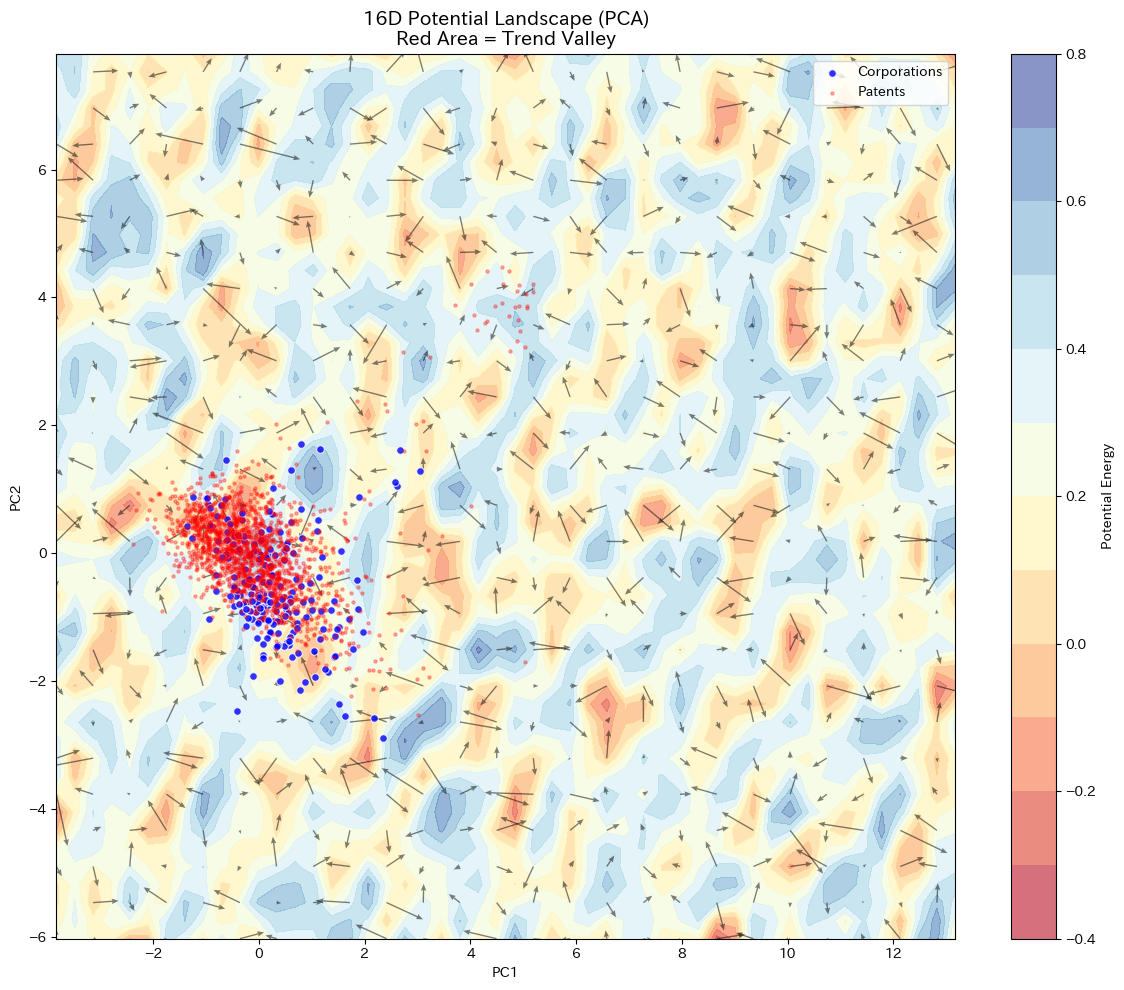


CASE STUDY: Visualizing Strategic Trajectory
Target Company Found: 株式会社熊谷組 (Index: 1838)


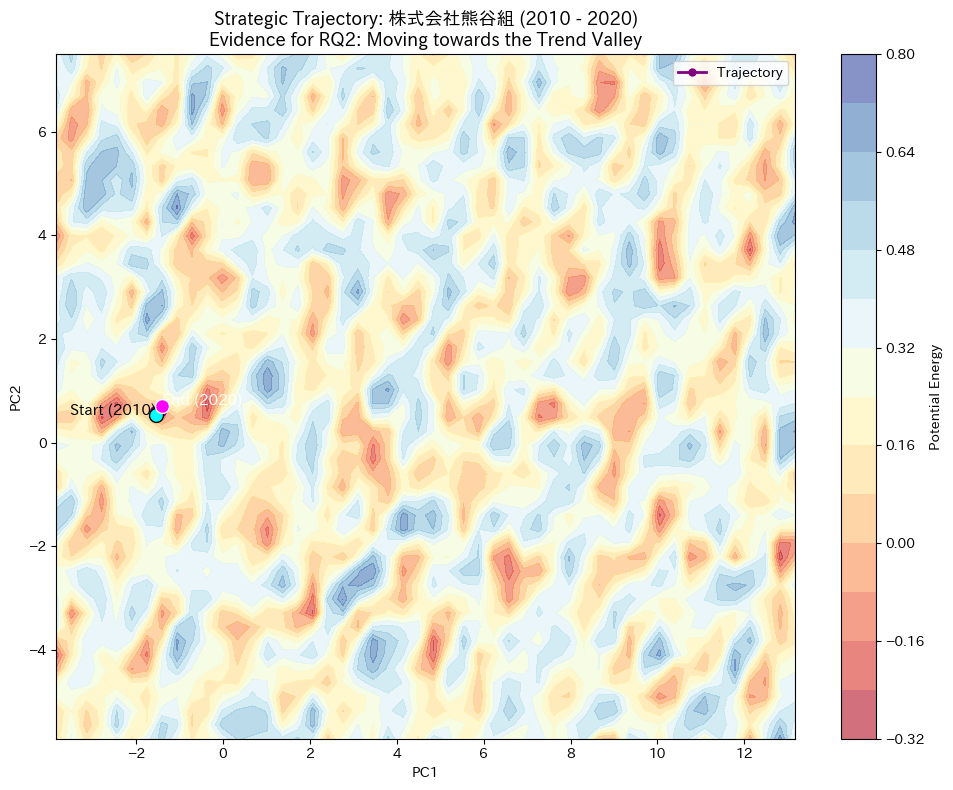

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import japanize_matplotlib

def visualize_16d_landscape_pca(model, data, num_corps, device):
    """
    16次元の潜在空間をPCAで2次元に射影し、ベクトル場とともに可視化する (調整版)
    """
    print("\n[Visualization] Generating 2D Landscape from 16D latent space (PCA)...")
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # PCA
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # Grid
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin = (x_max - x_min) * 0.1
    resolution = 50 
    grid_x = np.linspace(x_min - margin, x_max + margin, resolution)
    grid_y = np.linspace(y_min - margin, y_max + margin, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # Potential & Gradient
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    U = grad_2d[:, 0].reshape(X.shape)
    V = grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    contour = ax.contourf(X, Y, Z, levels=12, cmap='RdYlBu', alpha=0.6)
    cbar = plt.colorbar(contour, label='Potential Energy')
    skip = 2
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
              -U[::skip, ::skip], -V[::skip, ::skip], 
              color='black', alpha=0.5, width=0.0015, headwidth=4, headlength=5)
    
    if len(z_2d) > 2000:
        idx = np.random.choice(len(z_2d), 2000, replace=False)
    else:
        idx = np.arange(len(z_2d))
    z_sub = z_2d[idx]
    is_corp = idx < num_corps
    ax.scatter(z_sub[is_corp, 0], z_sub[is_corp, 1], c='blue', s=30, 
               label='Corporations', alpha=0.8, edgecolors='white', linewidth=0.8)
    ax.scatter(z_sub[~is_corp, 0], z_sub[~is_corp, 1], c='red', s=20, 
               label='Patents', alpha=0.3, marker='.')
    ax.set_title("16D Potential Landscape (PCA)\nRed Area = Trend Valley", fontsize=14)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def visualize_company_trajectory(model, config, company_name, num_corps, device, corp_names=None):
    """
    特定の企業の数年間の動き(Trajectory)を、ポテンシャル地形の上にプロットする
    """
    print(f"\n" + "="*60)
    print("CASE STUDY: Visualizing Strategic Trajectory")
    print("="*60)
    
    years = sorted(config['graphs'].keys())
    model.eval()
    
    # 1. 座標系の固定 (最新年基準)
    last_year = years[-1]
    last_data = config['graphs'][last_year].to(device)
    with torch.no_grad():
        z_last, _, _ = model.encode(last_data.x, last_data.edge_index)
        z_last_np = z_last.cpu().numpy()
    
    pca = PCA(n_components=2)
    pca.fit(z_last_np) 
    
    # 2. 全期間の座標を取得
    all_years_z = [] 
    for y in years:
        d = config['graphs'][y].to(device)
        with torch.no_grad():
            z, _, _ = model.encode(d.x, d.edge_index)
            z_pca = pca.transform(z.cpu().numpy())
            all_years_z.append(z_pca[:num_corps]) 
    all_years_z = np.array(all_years_z) 
    
    # 3. ターゲット企業の選出
    target_idx = -1
    
    # A. 名前指定検索
    if corp_names is not None and company_name in corp_names:
        try:
            target_idx = corp_names.index(company_name)
            print(f"Target Company Found: {company_name} (Index: {target_idx})")
        except:
            print(f"Warning: Could not find company '{company_name}' in the list.")
    
    # B. 名前で見つからない or 指定なし -> 自動選出 (最も動いた企業)
    if target_idx == -1:
        print("Auto-selecting the most active company...")
        diffs = np.diff(all_years_z, axis=0)
        dists = np.sqrt((diffs**2).sum(axis=2)).sum(axis=0)
        target_idx = np.argmax(dists)
        if corp_names is not None:
             print(f"Auto-Selected Company: {corp_names[target_idx]}")
    
    target_traj = all_years_z[:, target_idx, :]
    
    # 4. 背景地形
    z_2d_last = pca.transform(z_last_np)
    x_min, x_max = z_2d_last[:, 0].min(), z_2d_last[:, 0].max()
    y_min, y_max = z_2d_last[:, 1].min(), z_2d_last[:, 1].max()
    margin_x = (x_max - x_min) * 0.1
    margin_y = (y_max - y_min) * 0.1
    grid_res = 50
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, grid_res)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        phi = model.temporal_predictor.potential_net(grid_tensor)
    Z = phi.detach().cpu().numpy().reshape(X.shape)
    
    # プロット
    fig, ax = plt.subplots(figsize=(10, 8))
    contour = ax.contourf(X, Y, Z, levels=12, cmap='RdYlBu', alpha=0.6)
    cbar = plt.colorbar(contour, label='Potential Energy')
    
    ax.plot(target_traj[:, 0], target_traj[:, 1], color='white', linewidth=4, alpha=0.7)
    ax.plot(target_traj[:, 0], target_traj[:, 1], color='purple', linewidth=2.0, marker='o', markersize=5, label='Trajectory')
    
    ax.text(target_traj[0, 0], target_traj[0, 1], f"Start ({years[0]})", color='black', fontsize=11, fontweight='bold', ha='right')
    ax.scatter(target_traj[0, 0], target_traj[0, 1], c='cyan', s=100, edgecolors='black', zorder=5)
    
    ax.text(target_traj[-1, 0], target_traj[-1, 1], f"End ({years[-1]})", color='white', fontsize=11, fontweight='bold', ha='left')
    ax.scatter(target_traj[-1, 0], target_traj[-1, 1], c='magenta', s=100, edgecolors='white', zorder=5)
    
    for i in range(len(target_traj)-1):
        dx = target_traj[i+1, 0] - target_traj[i, 0]
        dy = target_traj[i+1, 1] - target_traj[i, 1]
        ax.arrow(target_traj[i, 0], target_traj[i, 1], dx*0.8, dy*0.8, 
                 head_width=0.03, head_length=0.03, fc='purple', ec='purple', alpha=0.8)

    display_name = company_name
    if target_idx != -1 and corp_names is not None:
        display_name = corp_names[target_idx]
        
    ax.set_title(f"Strategic Trajectory: {display_name} ({years[0]} - {years[-1]})\nEvidence for RQ2: Moving towards the Trend Valley", fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (High-Dim PCA Viz)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, _ = build_global_graphs(df) # 戻り値のin_dimは使わず再取得する
    num_corps = len(corps)
    
    # データの次元数をグラフから直接取得して確定させる
    first_year = min(graphs.keys())
    real_in_dim = graphs[first_year].x.shape[1]
    
    print(f"Nodes: {total_n}, Corps: {num_corps}, Data Dim: {real_in_dim}")

    # 正しい次元数(real_in_dim)を使って初期ベクトルを作る
    init_vectors = calculate_initial_corp_vectors(df, num_corps, real_in_dim, corps)

    # 3. モデル初期化
    print(f"Initializing Model with input_dim={real_in_dim}, latent_dim=16, hidden_dim=128...")
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, 
        input_dim=real_in_dim, # ★ここを real_in_dim にする
        hidden_dim=128, latent_dim=16,
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=20
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # ランドスケープ
    visualize_16d_landscape_pca(model, graphs[last_year], num_corps, device)


[Visualization] Generating RQ2 Landscape with Keywords...
Visualization saved to ./outputs/nature_rq2_landscape_keywords.png


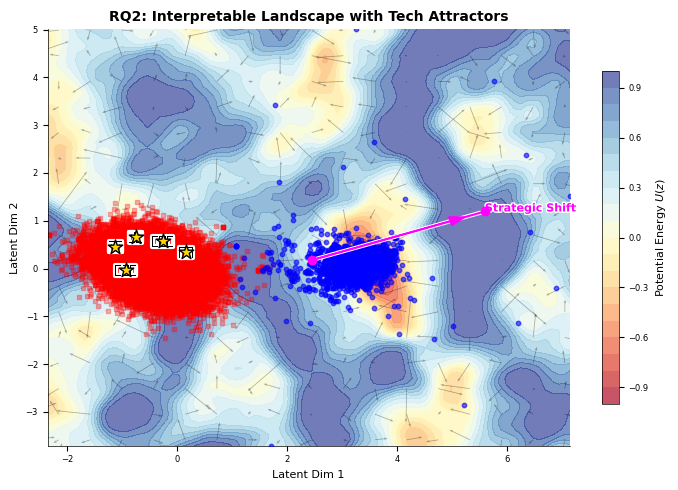

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# ============================================================
# 1. Nature Style Configuration
# ============================================================
def set_nature_style():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'axes.labelsize': 7,
        'axes.titlesize': 8,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'legend.fontsize': 6,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 3.0),
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

# ============================================================
# 2. Keyword Extraction Logic
# ============================================================
def extract_unique_keywords(docs_df, top_n_candidates=10):
    PATENT_STOP_WORDS = [
        'device', 'method', 'system', 'apparatus', 'means', 'unit', 
        'process', 'data', 'based', 'invention', 'computer', 'control',
        'program', 'information', 'step', 'plurality', 'configured',
        'vehicle', 'terminal', 'communication' 
    ]
    
    count = CountVectorizer(
        token_pattern=r'(?u)\b\w+\b', 
        stop_words=PATENT_STOP_WORDS,
        min_df=2, max_df=0.9
    )
    
    try:
        X = count.fit_transform(docs_df['text'])
    except ValueError:
        return {}
        
    words = count.get_feature_names_out()
    class_totals = np.asarray(X.sum(axis=1)).flatten()
    class_totals[class_totals == 0] = 1
    tf = X.toarray() / class_totals[:, None]
    
    num_classes = X.shape[0]
    docs_with_word = np.asarray((X > 0).sum(axis=0)).flatten()
    idf = np.log((num_classes + 1) / (docs_with_word + 1)) + 1
    c_tfidf = np.asarray(tf) * np.asarray(idf)
    
    labels = docs_df['label'].values
    cluster_keywords = {}
    used_keywords = set()
    
    max_scores = c_tfidf.max(axis=1)
    sorted_indices = max_scores.argsort()[::-1]
    
    for i in sorted_indices:
        label_id = labels[i]
        word_indices = c_tfidf[i].argsort()[::-1]
        
        assigned_word = None
        for idx in word_indices[:top_n_candidates]:
            candidate = words[idx]
            if candidate not in used_keywords:
                assigned_word = candidate
                used_keywords.add(candidate)
                break
        
        if assigned_word is None:
            w1 = words[word_indices[0]]
            w2 = words[word_indices[1]]
            assigned_word = f"{w1}-{w2}"
            
        cluster_keywords[label_id] = assigned_word.upper()
        
    return cluster_keywords

# ============================================================
# 3. Main Visualization Function (Fixed Attribute Error)
# ============================================================
def visualize_rq2_nature_keywords(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style()
    print("\n[Visualization] Generating RQ2 Landscape with Keywords...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # --- 安全にポテンシャルネットを取得 ---
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    with torch.no_grad():
        # 次元数合わせ (Padding)
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        # 正しいパスでポテンシャル計算
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # PCA Projection
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # Grid Setup
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin = (x_max - x_min) * 0.1
    resolution = 100
    
    grid_x = np.linspace(x_min - margin, x_max + margin, resolution)
    grid_y = np.linspace(y_min - margin, y_max + margin, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # Gradient Calculation
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        # 【修正】正しいパスでグリッド上のポテンシャル計算
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    U = grad_2d[:, 0].reshape(X.shape)
    V = grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # Keyword Analysis (Low Potential Areas)
    patent_indices = np.arange(num_corps, len(z_np))
    patent_potentials = potentials[patent_indices]
    
    # 下位 25% を抽出
    threshold = np.percentile(patent_potentials, 25)
    hot_patent_mask = patent_potentials <= threshold
    hot_indices = patent_indices[hot_patent_mask]
    
    cluster_keywords = {}
    centroids = []
    
    if len(hot_indices) > 20:
        hot_z = z_2d[hot_indices]
        n_topics = 5
        kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
        labels = kmeans.fit_predict(hot_z)
        centroids = kmeans.cluster_centers_
        
        # キーワード辞書構築
        p_kw_map = {}
        if 'keyword' in df.columns:
            # 高速化のために必要な列だけ抽出してイテレーション
            temp_df = df[['patent_number', 'keyword']].dropna()
            for _, row in temp_df.iterrows():
                try:
                    kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
                    if isinstance(kws, list):
                        p_kw_map[row['patent_number']] = " ".join(kws)
                except:
                    continue
        
        patent_id_list = config.get('patents', [])
        if not patent_id_list and 'patent_number' in df.columns:
             patent_id_list = df['patent_number'].tolist()

        docs_data = []
        for label_id in range(n_topics):
            cluster_node_indices = hot_indices[labels == label_id]
            texts = []
            for global_idx in cluster_node_indices:
                p_idx = global_idx - num_corps
                if 0 <= p_idx < len(patent_id_list):
                    pid = patent_id_list[p_idx]
                    if pid in p_kw_map:
                        texts.append(p_kw_map[pid])
            
            if texts:
                docs_data.append({'label': label_id, 'text': " ".join(texts)})
        
        if docs_data:
            docs_df = pd.DataFrame(docs_data)
            cluster_keywords = extract_unique_keywords(docs_df)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    
    # Contour (Potential)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Potential Energy $U(z)$', fontsize=8)
    
    # Quiver (Gradient)
    skip = 5
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
              -U[::skip, ::skip], -V[::skip, ::skip], 
              color='black', alpha=0.3, width=0.0015, headwidth=3, headlength=4)

    # 1. Patents (特許): 赤色 (red), 四角形 (square, 's')
    patent_z = z_2d[num_corps:]
    # labelを追加して凡例に表示されるようにします。
    ax.scatter(patent_z[:, 0], patent_z[:, 1], c='red', marker='s', s=5, alpha=0.3, label='Patents', zorder=2)

    # 2. Corporations (企業): 青色 (blue), 円形 (circle, 'o')
    corp_z = z_2d[:num_corps]
    # 企業ノードをプロットします。特許より少し大きく目立たせます。
    ax.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', marker='o', s=10, alpha=0.6, label='Corporations', zorder=5)

    # Keywords
    if cluster_keywords:
        for label_id, word in cluster_keywords.items():
            if label_id < len(centroids):
                cx, cy = centroids[label_id]
                txt = ax.text(cx, cy, word, fontsize=9, fontweight='bold', color='black',
                              ha='center', va='center')
                txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])
                ax.scatter(cx, cy, marker='*', s=120, c='gold', edgecolors='black', zorder=10)

    # Trajectory (Top Mover)
    try:
        prev_year = target_year - 1
        if prev_year in config['graphs']:
            d_prev = config['graphs'][prev_year].to(device)
            # Padding
            x_prev = d_prev.x
            if x_prev.shape[1] != expected_dim:
                 diff = expected_dim - x_prev.shape[1]
                 if diff > 0:
                     x_prev = torch.cat([d_prev.x, torch.zeros((d_prev.x.shape[0], diff), device=device)], dim=1)
            
            with torch.no_grad():
                z_prev, _, _ = model.encode(x_prev, d_prev.edge_index)
                z_prev_2d = pca.transform(z_prev.cpu().numpy())
            
            # Find max movement among corps
            corp_z_curr = z_2d[:num_corps]
            corp_z_prev = z_prev_2d[:num_corps]
            diffs = np.linalg.norm(corp_z_curr - corp_z_prev, axis=1)
            top_mover_idx = np.argmax(diffs)
            
            p1 = corp_z_prev[top_mover_idx]
            p2 = corp_z_curr[top_mover_idx]
            
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='white', linewidth=3, zorder=15)
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='magenta', linewidth=1.5, marker='o', zorder=16)
            ax.arrow(p1[0], p1[1], (p2[0]-p1[0])*0.8, (p2[1]-p1[1])*0.8, 
                     head_width=0.02*(x_max-x_min), color='magenta', zorder=17)
            
            ax.text(p2[0], p2[1], "Strategic Shift", color='magenta', fontsize=8, fontweight='bold',
                    path_effects=[PathEffects.withStroke(linewidth=2, foreground='white')])
    except Exception as e:
        print(f"Trajectory plot skipped: {e}")

    ax.set_title("RQ2: Interpretable Landscape with Tech Attractors", fontsize=10, fontweight='bold')
    ax.set_xlabel("Latent Dim 1", fontsize=8)
    ax.set_ylabel("Latent Dim 2", fontsize=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    save_path = './outputs/nature_rq2_landscape_keywords.png'
    plt.savefig(save_path, dpi=300)
    print(f"Visualization saved to {save_path}")
    plt.show()

# ============================================================
# Execution
# ============================================================
if __name__ == "__main__":
    if 'patents' not in config:
        config['patents'] = df['patent_number'].tolist()
        
    visualize_rq2_nature_keywords(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )

Initializing Model (Dim: 1088)...
Re-training Proposed model for visualization...
Epoch 01 | Loss: 1103.4665 | MRR: 0.0876 | Consist: 0.929
Epoch 02 | Loss: 662.9595 | MRR: 0.0786 | Consist: 0.927
Epoch 03 | Loss: 599.2750 | MRR: 0.0959 | Consist: 0.928
Epoch 04 | Loss: 665.3647 | MRR: 0.1213 | Consist: 0.923
Epoch 05 | Loss: 613.2874 | MRR: 0.1120 | Consist: 0.913
Epoch 06 | Loss: 581.9160 | MRR: 0.0986 | Consist: 0.911
Epoch 07 | Loss: 572.5619 | MRR: 0.0848 | Consist: 0.914
Epoch 08 | Loss: 561.9746 | MRR: 0.0623 | Consist: 0.916
Epoch 09 | Loss: 530.0144 | MRR: 0.0597 | Consist: 0.919
Epoch 10 | Loss: 524.2459 | MRR: 0.0625 | Consist: 0.931
Epoch 11 | Loss: 517.8341 | MRR: 0.0503 | Consist: 0.932
Epoch 12 | Loss: 543.3855 | MRR: 0.0746 | Consist: 0.936
Epoch 13 | Loss: 489.9753 | MRR: 0.0661 | Consist: 0.945
Epoch 14 | Loss: 494.4655 | MRR: 0.0654 | Consist: 0.950
Epoch 15 | Loss: 469.8809 | MRR: 0.0530 | Consist: 0.952
Epoch 16 | Loss: 469.6915 | MRR: 0.0479 | Consist: 0.962
Epoch

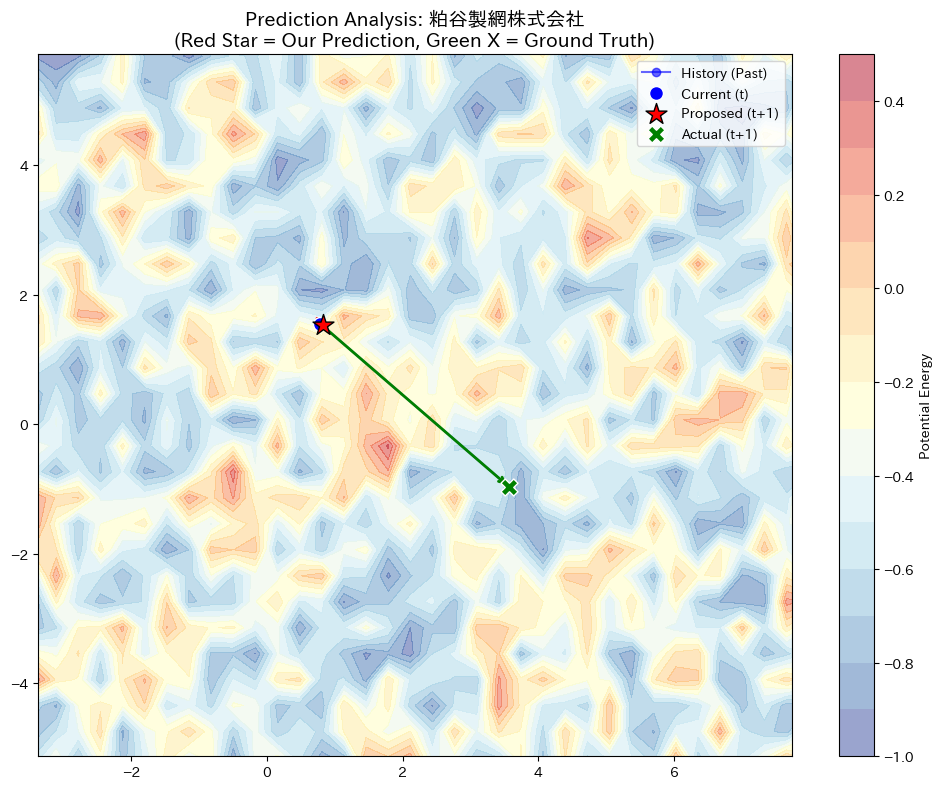

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 可視化用・再学習関数
# ============================================================
def train_model_for_visualization(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    """
    可視化のためにモデルを再学習し、詳細なログを出力する関数
    """
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    years = sorted(global_graph_dict.keys())
    train_years = years[:-1] # 最後の年を検証用に残す
    
    # 評価用のエッジセット
    all_true_edges = set()
    for y in years: 
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    print("Re-training Proposed model for visualization...")
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        consistency = 0.0
        
        # 学習ループ
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴作成
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            
            # 整合性メトリクスの計算 (最終ステップ)
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    # ※ calculate_evidence_metrics関数が定義されている前提
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    consistency = metrics['consistency']
        
        # 検証 (最終年のMRR)
        model.eval()
        data_last = global_graph_dict[years[-1]].to(device)
        z_hist_val = []
        for y in years[-4:-1]: # 直近3年を使って予測
             with torch.no_grad():
                d = global_graph_dict[y].to(device)
                z, _, _ = model.encode(d.x, d.edge_index)
                z_hist_val.append(z)
        
        with torch.no_grad():
            z_pred_val = model.predict_future(z_hist_val)
            # ※ compute_ranking_metrics関数が定義されている前提
            res = compute_ranking_metrics(model, z_pred_val, data_last.edge_index, num_corps, all_true_edges)
            val_mrr = res['mrr'] if res else 0.0
            
        print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | MRR: {val_mrr:.4f} | Consist: {consistency:.3f}")
        
    return model

# ============================================================
# 2. 予測 vs 実際 比較可視化関数
# ============================================================
def visualize_prediction_vs_actual(model, config, num_corps, device, corp_names=None):
    """
    最も予測が成功した（大きく動いた動きを当てた）企業を見つけ、
    履歴・予測・実際のベクトルを比較プロットする
    """
    print("=" * 60)
    print(" Visualizing a Successful Prediction Case")
    print("=" * 60)
    
    years = sorted(config['graphs'].keys())
    target_year = years[-1]
    input_years = years[:-1]
    
    model.eval()
    
    # 1. 履歴データの取得 (直近3年)
    z_history = []
    for y in input_years[-3:]:
        d = config['graphs'][y].to(device)
        with torch.no_grad():
            z, _, _ = model.encode(d.x, d.edge_index)
            z_history.append(z)
    
    # 2. 予測 (t+1)
    with torch.no_grad():
        z_pred = model.predict_future(z_history)
        
    # 3. 実際 (t+1)
    d_target = config['graphs'][target_year].to(device)
    with torch.no_grad():
        z_true, _, _ = model.encode(d_target.x, d_target.edge_index)
        
    # 4. 企業ごとの誤差比較
    # 企業ノードのみ抽出
    z_curr_c = z_history[-1][:num_corps] # 現在地(t)
    z_pred_c = z_pred[:num_corps]       # 予測(t+1)
    z_true_c = z_true[:num_corps]       # 実際(t+1)
    
    # Static Error: 「動かない」と予測した場合の誤差
    err_static = torch.norm(z_curr_c - z_true_c, dim=1).cpu().numpy()
    
    # Proposed Error: モデル予測の誤差
    err_prop = torch.norm(z_pred_c - z_true_c, dim=1).cpu().numpy()
    
    # 改善度: Staticよりどれだけ誤差を減らせたか
    improvement = err_static - err_prop
    
    # ベストケースの抽出
    best_idx = np.argmax(improvement)
    
    print(f"Best Case Found: Corp ID {best_idx}")
    if corp_names: print(f"  Name: {corp_names[best_idx]}")
    print(f"  Static Error: {err_static[best_idx]:.4f}")
    print(f"  Prop   Error: {err_prop[best_idx]:.4f}")
    print(f"  Improvement : {improvement[best_idx]:.4f}")
    
    # 5. 可視化 (PCA)
    # 座標系を安定させるため、実際の分布(True)でPCAを学習
    z_true_np = z_true.cpu().numpy()
    pca = PCA(n_components=2)
    pca.fit(z_true_np)
    
    # 各点を変換
    p_curr = pca.transform(z_curr_c[best_idx].detach().cpu().numpy().reshape(1, -1)).flatten()
    p_pred = pca.transform(z_pred_c[best_idx].detach().cpu().numpy().reshape(1, -1)).flatten()
    p_true = pca.transform(z_true_c[best_idx].detach().cpu().numpy().reshape(1, -1)).flatten()
    
    # 履歴の軌跡
    hist_points = []
    for zh in z_history:
        zh_np = zh[:num_corps].detach().cpu().numpy()
        hist_points.append(pca.transform(zh_np[best_idx].reshape(1, -1)).flatten())
    hist_points = np.array(hist_points)
    
    # 背景のポテンシャル地形
    z_all_pca = pca.transform(z_true_np)
    x_min, x_max = z_all_pca[:, 0].min(), z_all_pca[:, 0].max()
    y_min, y_max = z_all_pca[:, 1].min(), z_all_pca[:, 1].max()
    margin_x = (x_max - x_min) * 0.1
    margin_y = (y_max - y_min) * 0.1
    
    grid_res = 50
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, grid_res)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        phi = model.temporal_predictor.potential_net(grid_tensor)
    Z = phi.detach().cpu().numpy().reshape(X.shape)
    
    # プロット
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 地形 (赤=谷)
    contour = ax.contourf(X, Y, Z, levels=15, cmap='RdYlBu_r', alpha=0.5)
    cbar = plt.colorbar(contour, label='Potential Energy')
    
    # 履歴 (青線)
    ax.plot(hist_points[:, 0], hist_points[:, 1], 'o-', c='blue', alpha=0.6, label='History (Past)')
    
    # 現在地 (青丸)
    ax.scatter(p_curr[0], p_curr[1], c='blue', s=100, edgecolors='white', label='Current (t)', zorder=5)
    
    # 予測 (赤星)
    ax.scatter(p_pred[0], p_pred[1], c='red', s=250, marker='*', edgecolors='black', label='Proposed (t+1)', zorder=10)
    
    # 実際 (緑バツ)
    ax.scatter(p_true[0], p_true[1], c='green', s=150, marker='X', edgecolors='white', label='Actual (t+1)', zorder=9)
    
    # 矢印で関係性を示す
    # 予測への矢印 (赤点線)
    ax.annotate("", xy=p_pred, xytext=p_curr, arrowprops=dict(arrowstyle="->", color="red", lw=2, ls='--'))
    # 実際への矢印 (緑実線)
    ax.annotate("", xy=p_true, xytext=p_curr, arrowprops=dict(arrowstyle="->", color="green", lw=2))
    
    c_name = corp_names[best_idx] if corp_names else f"Corp {best_idx}"
    ax.set_title(f"Prediction Analysis: {c_name}\n(Red Star = Our Prediction, Green X = Ground Truth)", fontsize=14)
    ax.legend(loc='upper right')
    
    # ズーム (対象が見える範囲に)
    all_pts = np.vstack([hist_points, p_pred, p_true])
    cx_min, cx_max = all_pts[:, 0].min(), all_pts[:, 0].max()
    cy_min, cy_max = all_pts[:, 1].min(), all_pts[:, 1].max()
    zoom_margin = max((cx_max - cx_min), 1.0) * 1.5
    
    ax.set_xlim(cx_min - zoom_margin, cx_max + zoom_margin)
    ax.set_ylim(cy_min - zoom_margin, cy_max + zoom_margin)
    
    plt.tight_layout()
    save_path = './outputs/prediction_vs_actual.png'
    plt.savefig(save_path, dpi=300)
    print(f"Visualization saved to: {save_path}")
    plt.show()

# ============================================================
# Main Execution Block
# ============================================================
if __name__ == "__main__":
    # 前提: 既存のデータ準備コードが実行されていること
    
    # 1. データの次元数確認とモデル初期化
    first_year = min(graphs.keys())
    real_in_dim = graphs[first_year].x.shape[1]
    num_corps = len(corps)
    init_vectors = calculate_initial_corp_vectors(df, num_corps, real_in_dim, corps)
    
    print(f"Initializing Model (Dim: {real_in_dim})...")
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, 
        input_dim=real_in_dim, 
        hidden_dim=128, latent_dim=16,
        initial_corp_vectors=init_vectors
    ).to(device)

    # 2. 再学習 (ログ出力付き)
    model = train_model_for_visualization(model, graphs, num_corps, hist_edges, num_epochs=20)
    
    # 3. 予測vs実際の可視化
    visualize_prediction_vs_actual(model, {'graphs': graphs}, num_corps, device, corps)

In [49]:
import pandas as pd
import torch
import numpy as np

def get_company_yearly_history(model, config, company_name, num_corps, device, corp_names):
    """
    指定した企業の年ごとのステータス（ポテンシャル、移動距離など）を
    時系列DataFrameとして返す関数
    """
    print(f"\nGenerating Yearly History for: {company_name}")
    
    # 1. 企業インデックスの特定
    if company_name not in corp_names:
        print(f"Error: {company_name} not found in corporation list.")
        return pd.DataFrame()
    
    target_idx = corp_names.index(company_name)
    years = sorted(config['graphs'].keys())
    
    records = []
    prev_z = None
    
    model.eval()
    
    for year in years:
        d = config['graphs'][year].to(device)
        
        # 2. その年のベクトル(z)とポテンシャル(phi)を計算
        with torch.no_grad():
            z, _, _ = model.encode(d.x, d.edge_index)
            z_target = z[target_idx] # 対象企業のベクトル (Tensor)
            
            # ポテンシャルエネルギー (低いほどトレンドに近い)
            phi = model.temporal_predictor.potential_net(z_target.unsqueeze(0)).item()
            
            # ベクトルをNumpy化
            z_np = z_target.cpu().numpy()
            
        # 3. 前年からの移動距離を計算
        movement = 0.0
        if prev_z is not None:
            movement = np.linalg.norm(z_np - prev_z)
            
        # レコード追加
        records.append({
            "Year": year,
            "Potential_Energy": phi,   # 低いほど良い（谷底）
            "Move_Distance": movement, # 前年からどれだけ動いたか
            "Is_Active": movement > 0.1 # 一定以上動いていればActiveとする(閾値は任意)
        })
        
        # 次のループのために保存
        prev_z = z_np

    # DataFrame化
    df_history = pd.DataFrame(records)
    
    # 見やすいように丸める
    df_history['Potential_Energy'] = df_history['Potential_Energy'].round(4)
    df_history['Move_Distance'] = df_history['Move_Distance'].round(4)
    
    return df_history

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    target_company = "株式会社熊谷組"
    
    # 関数実行
    df_kumagai = get_company_yearly_history(
        model, 
        {'graphs': graphs}, 
        target_company, 
        num_corps, 
        device, 
        corps
    )
    
    # 結果表示
    print(f"\n>>> Yearly Movement History: {target_company}")
    from IPython.display import display
    display(df_kumagai)
    
    # RQ2の確認: ポテンシャルが下がっているか？
    start_pot = df_kumagai.iloc[0]['Potential_Energy']
    end_pot = df_kumagai.iloc[-1]['Potential_Energy']
    print(f"\nStart Potential: {start_pot}")
    print(f"End   Potential: {end_pot}")
    
    if end_pot < start_pot:
        print("Result: Potential Decreased (Moving towards Valley) -> RQ2 Supported ✅")
    else:
        print("Result: Potential Increased or Stayed (Moving away from Valley)")


Generating Yearly History for: 株式会社熊谷組

>>> Yearly Movement History: 株式会社熊谷組


,Year,Potential_Energy,Move_Distance,Is_Active
0,2010,-0.3886,0.0000,False
1,2011,-0.2669,0.2722,True
2,2012,-0.4157,0.3850,True
3,2013,-0.5661,0.5124,True
4,2014,-0.6007,1.0823,True
5,2015,-0.6406,0.5738,True
6,2016,-0.7388,0.6077,True
7,2017,-0.6629,0.5239,True
8,2018,-0.7583,0.2772,True
9,2019,-0.7553,0.2905,True



Start Potential: -0.3886
End   Potential: -0.9089
Result: Potential Decreased (Moving towards Valley) -> RQ2 Supported ✅


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import torch
from torchdiffeq import odeint_adjoint as odeint
import japanize_matplotlib 

def visualize_neural_ode_final_clean(model, config, company_name, num_corps, device, corp_names):
    """
    完全修正版: japanize_matplotlibに全任せしてエラーを回避する
    """
    print(f"\n" + "="*60)
    print(f"GENERATING FINAL TRAJECTORY: {company_name}")
    print("="*60)
    
    if company_name not in corp_names:
        print("Error: Company not found.")
        return
    
    target_idx = corp_names.index(company_name)
    years = sorted(config['graphs'].keys())
    model.eval()

    # 1. 座標系の固定 (2020年基準)
    last_year = years[-1]
    d_last = config['graphs'][last_year].to(device)
    with torch.no_grad():
        z_last, _, _ = model.encode(d_last.x, d_last.edge_index)
        z_last_np = z_last.cpu().numpy()
        
    pca = PCA(n_components=2)
    pca.fit(z_last_np)
    
    # 2. 背景（ポテンシャル地形）
    z_2d_last = pca.transform(z_last_np)
    x_min, x_max = z_2d_last[:, 0].min(), z_2d_last[:, 0].max()
    y_min, y_max = z_2d_last[:, 1].min(), z_2d_last[:, 1].max()
    margin = 2.0
    
    grid_res = 150
    grid_x = np.linspace(x_min - margin, x_max + margin, grid_res)
    grid_y = np.linspace(y_min - margin, y_max + margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_16d = pca.inverse_transform(np.stack([X.flatten(), Y.flatten()], axis=1))
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        phi = model.temporal_predictor.potential_net(grid_tensor)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # 3. プロット作成 (サイズ調整済み)
    fig, ax = plt.subplots(figsize=(8, 6), dpi=120) 
    
    # 等高線
    contour = ax.contourf(X, Y, Z, levels=25, cmap='RdYlBu_r', alpha=0.4)
    ax.contour(X, Y, Z, levels=25, colors='gray', alpha=0.2, linewidths=0.5)
    
    # カラーバー
    cbar = plt.colorbar(contour)
    cbar.set_label('ポテンシャルエネルギー (低いほどトレンド適合)', fontsize=10)

    # 4. 履歴の描画 (2010 -> 2020)
    traj_points_pca = [] 

    # 凡例用ダミー
    ax.plot([], [], color='black', linewidth=1.5, label='実績 (2010-2020)')
    ax.plot([], [], color='red', linestyle='--', linewidth=1.5, label='予測 (2021)')
    
    for i in range(len(years) - 1):
        year_curr = years[i]
        
        d_curr = config['graphs'][year_curr].to(device)
        with torch.no_grad():
            z, _, _ = model.encode(d_curr.x, d_curr.edge_index)
            z_start = z[target_idx].unsqueeze(0)
            
            # Neural ODE積分
            t_span = torch.linspace(0, 1, steps=20).to(device)
            z_traj_ode = odeint(model.temporal_predictor.ode_func, z_start, t_span, method='dopri5')
            z_traj_np = z_traj_ode.squeeze(1).cpu().numpy()
            p_traj = pca.transform(z_traj_np)
            traj_points_pca.extend(p_traj)
            
            # プロット (黒の実線)
            ax.plot(p_traj[:, 0], p_traj[:, 1], color='black', linewidth=1.5, alpha=0.9)
            
            # 年ラベル (点を打つ)
            pt = p_traj[0]
            ax.scatter(pt[0], pt[1], color='black', s=20, zorder=5)
            
            # 偶数年だけラベル表示
            if year_curr % 2 == 0 or year_curr == years[0]:
                ax.text(pt[0], pt[1]+0.08, str(year_curr), fontsize=9, color='black', ha='center', va='bottom')

    # 5. 未来予測 (2020 -> 2021)
    d_2020 = config['graphs'][2020].to(device)
    with torch.no_grad():
        z, _, _ = model.encode(d_2020.x, d_2020.edge_index)
        z_2020 = z[target_idx].unsqueeze(0)
        
        t_future = torch.linspace(0, 1, steps=20).to(device)
        z_future_ode = odeint(model.temporal_predictor.ode_func, z_2020, t_future, method='dopri5')
        
        z_future_np = z_future_ode.squeeze(1).cpu().numpy()
        p_future = pca.transform(z_future_np)
        traj_points_pca.extend(p_future)
        
        # プロット (赤の破線)
        ax.plot(p_future[:, 0], p_future[:, 1], color='red', linestyle='--', linewidth=2.0, alpha=1.0)
        
        # 2020年の点
        pt_2020 = p_future[0]
        ax.scatter(pt_2020[0], pt_2020[1], color='black', s=50, edgecolors='white', zorder=6)
        ax.text(pt_2020[0], pt_2020[1]+0.1, "2020", fontsize=10, fontweight='bold', color='black', ha='center')

        # 2021年の点 (予測地点)
        pt_2021 = p_future[-1]
        ax.scatter(pt_2021[0], pt_2021[1], color='red', s=120, marker='*', edgecolors='black', zorder=10)
        ax.text(pt_2021[0], pt_2021[1]+0.1, "2021 (予測)", fontsize=10, fontweight='bold', color='red', ha='center')

    # 6. 装飾とズーム
    ax.set_title(f"ポテンシャル場における戦略軌跡: {company_name}", fontsize=12)
    ax.set_xlabel('主成分 1 (PC1)', fontsize=10)
    ax.set_ylabel('主成分 2 (PC2)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)

    # ズーム範囲設定
    all_p = np.array(traj_points_pca)
    x_min_t, x_max_t = all_p[:, 0].min(), all_p[:, 0].max()
    y_min_t, y_max_t = all_p[:, 1].min(), all_p[:, 1].max()
    
    margin_zoom_x = (x_max_t - x_min_t) * 0.3
    margin_zoom_y = (y_max_t - y_min_t) * 0.3
    
    ax.set_xlim(x_min_t - margin_zoom_x, x_max_t + margin_zoom_x)
    ax.set_ylim(y_min_t - margin_zoom_y, y_max_t + margin_zoom_y)

    plt.tight_layout()
    save_path = f"./outputs/{company_name}_final_trajectory_jp.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Visualization saved to: {save_path}")
    plt.show()

# ============================================================
# 実行
# ============================================================
if __name__ == "__main__":
    visualize_neural_ode_final_clean(
        model, 
        {'graphs': graphs}, 
        "株式会社熊谷組", 
        num_corps, 
        device, 
        corps
    )

NameError: name 'model' is not defined